# Low-latency fan-out transport — measurements

A shared-memory-to-shared-memory relay, measured **over two real networks**:

```
host A                                     host B
producer -> shm ring -> sender  ==LINK==>  receiver -> shm ring -> consumer
 (given)                (ours)              (ours)                 (given)

LINK is one of two real networks:
  direct   one hop, both hosts in one subnet      ~35 us one way
  routed   across regions, several hops           ~33.5 ms one way
```

| | **direct path** | **routed path** |
|---|---|---|
| topology | two hosts, one subnet, one hop | routed across regions |
| one-way p50 | **35 µs** | **33.5 ms** |
| what it can measure | the transport itself | whether the transport's *rules* hold |
| our code's share | ~620 ns, 1.8% | ~620 ns, 0.002% |

The two are not alternatives; they answer different questions. On the direct path the relay is 1.8%
of the total, so it is the path on which our own design decisions are visible at all. On the routed
path the relay is invisible — three orders of magnitude below the distance — so what it tests is
whether the *rules* survive a network permitted to reorder, drop and re-route, and whether the loss
regime the task specifies (0.01–1%) can be reached. Sections 1–12 are the direct path; section 13 is
the routed one.

Design reasoning is in [SOLUTION.md](SOLUTION.md); this notebook is the evidence.

**Everything here crosses a real NIC.** Loopback understates latency by roughly 15x: it has
no driver, no NIC and no wire, so it measures the software path only. No figure in this
notebook comes from a same-host run — loopback survives in the codebase solely as a
functional check that a code path works at all.

**Headline on the direct path, 200k msg/s, 20M samples per repetition:**

| | |
|---|---|
| p50 | **35.0 µs** |
| p99 | **39.3 µs** |
| p99.9 | **49.8 µs** |
| p99.99 | **68.1 µs** |
| p99.999 | 1.06 ms |
| drop rate | **0.0000%** |
| our code's share of the 35 µs | **~620 ns (1.8%)** |

**Headline on the routed path, 50k msg/s, six interleaved blocks of 0.78M samples each:**

| | median of six blocks | block range |
|---|---|---|
| p50 | **34.20 ms** | 33.57 .. 34.68 ms |
| p99 | **34.36 ms** | 33.89 .. 36.31 ms |
| p99.9 | **35.19 ms** | 34.20 .. 38.09 ms |
| p99.99 | 36.30 ms | 34.37 .. 38.87 ms |
| first-copy loss | **0.156%** | 0.155 .. 0.158% |
| reordered datagrams | **0** | 0 in every block |
| our code's share of the 33.5 ms | **~620 ns (0.002%)** | — |

Two things to read off that second table rather than from the medians alone. **The block range is the
uncertainty, not a spread across repetitions of one run** — the path's own median moves about 1.1 ms
between blocks with nothing changed, which is why configuration comparisons here rest on the
single-clock loss counters rather than on latency. And **p99.99 rests on roughly 78 observations per
block**, below the hundred a quantile needs, so it is shown unbolded and nothing beyond it is
reported; the direct path's p99.999 is unbolded for the same reason.

Findings worth the read:

1. **The transport is not the bottleneck; the network path is.** Per-stage timing
   shows our sender costs 305 ns, publishing into the receiver's ring costs 50 ns,
   and the consumer picks it up 264 ns later. The remaining 34.3 µs is kernel TX,
   NIC, wire and kernel RX. See figure 2.
2. **Loss tracks packet rate, not message rate.** The only loss anywhere in the
   sweep (0.0088%) is at the *highest packet rate*, which is 1M msg/s -- not at 2M,
   where batching pushes packets per second back down. See figure 7.
3. **Latency spikes are not uniformly distributed — they arrive in bursts**, and the
   larger the spike the more strictly that holds. Every excursion above 500 µs, in
   every repetition, belongs to a burst of consecutive messages; not one occurs in
   isolation. A whole 20M-message run's far tail comes down to one to three discrete
   events. See figure 3.
4. **Those bursts are a queue draining.** All 213 messages over 1 ms are
   wire-dominated, and they arrive as consecutive sequence ids whose latency falls by
   the inter-message interval. See figures 4-5.
5. **Loss is bursty too, which means duplication buys almost nothing here.** This path
   loses 2 × 10⁻⁵ of messages, and those losses arrive in a handful of events of ~70
   consecutive datagrams. A copy sent microseconds after its original dies inside the
   same burst: 2 rescues out of 485 lost datagrams. See figure 7b.
6. **Fan-out is limited by packets, not by our code.** Each receiver costs one more
   packet per datagram, so the NIC's packet-rate ceiling divides the achievable message
   rate by receiver count. At ten receivers we are already at 97% of it. See figure 8.
7. **The strict delivery rule survives a routed network, which was the open risk.** The gate
   publishes only strictly increasing sequence ids, so a reordered datagram is *dropped* rather
   than delivered late — costless on one hop, potentially expensive across a routed path. Measured
   there: **zero reordering in 1,549,105 datagrams**, and MTU 1500 end to end. See section 13.
8. **The routed path is where loss becomes measurable, and where redundancy is resolved
   against.** Loss runs 20-80x the direct path's and rises with offered rate, reaching 0.18% at
   50k msg/s — and it arrives in bursts, one of them a single ~39 ms outage. Six interleaved
   blocks give redundancy a *net cost* in delivery (+170 undelivered frames, sign p = 0.031) and
   no separable latency effect. See section 13.
9. **Absolute one-way latency is more trustworthy on the long path, not less.** The inter-host
   clock offset is larger there in absolute terms, but it is 0.08% of a 33.5 ms transit instead of
   comparable to a 35 µs one — and the measured one-way sits within 0.3% of half the round trip.
   The direct path's figures carry ±4 µs of clock uncertainty unless a run is bracketed.

## Methodology

**Metric collection cannot be allowed to perturb the metric.** Samples go into
memory reserved *and page-touched* before the first sample, `record()` is a couple
of stores, and nothing reaches the filesystem until the run is over. Writing one CSV
line per message from inside the measurement loop puts a `write()` on the timing path:
on a disk-backed filesystem that alone measures ~1 ms at p99.99, and even on tmpfs a
`write` can stall unpredictably. Every number below was collected with the
allocation-free path.

**Sample counts are sized to the percentile being claimed.** A percentile needs roughly a
hundred observations beyond it to mean anything, so p99.999 needs ~10M samples. The direct-path
rate sweep uses 20M samples per repetition wherever the rate allows it in a sane run length; at
100 and 10k events/second it cannot -- 20M samples at 100/s is two days -- so those rows are
marked and their far tail is *not* reported. The routed path runs 0.8-4M samples per arm, which
supports p99.9 comfortably and p99.99 marginally, so nothing beyond p99.99 is claimed there.

**Percentiles are pooled, not averaged across files.** A percentile of N*M samples is an estimate
from N*M samples; the median of N per-file percentiles is a different quantity and at a far tail it
is wrong by multiples, because the median across files discards exactly the files holding the rare
events. On these runs the two disagree by up to 719% at p99.99. The spread shown beside a figure is
the range of per-repetition pooled values -- a *within-session* spread, which describes variation
inside one window and is blind to anything that changes between windows.

**Configurations are compared in interleaved blocks, not one after the other.** Each arm is
measured once per block, blocks repeat, and the arm order reverses on alternate blocks so the linear
component of any clock drift cancels across a pair. The verdict is an exact two-sided sign test over
per-block differences, reported alongside how far the *reference arm alone* moves between blocks --
an effect smaller than that is not resolved, whatever the medians say. Six blocks is the floor and
it is arithmetic: with every block agreeing the smallest attainable p is 2/2**n, so three blocks
cannot reach significance at any effect size.

**Which figures need clock agreement, and which do not.** Only legs spanning both hosts do. On the
direct path the inter-host offset wanders 8.8 us over an hour, which is the same size as most
effects being compared, so cross-host absolutes there carry +/-4 us unless a run is bracketed by
idle offset probes. Single-host legs -- source-ring wait, receiving-kernel delivery, ring publish --
and the loss and delivery counters are exact and need no correction at all, which is why they carry
most of the conclusions.

**Other rules applied throughout:**

- Steady state only: the stream runs continuously, consumers attach at the live edge after an 8 s
  warm-up, and the first samples of each run are discarded.
- Cores are verified idle, isolated and free of SMT siblings before every run
  (`scripts/check_cores.sh`), which refuses to measure otherwise. It caught a leftover producer
  pinned to a measurement core twice during this work.
- A run that did not happen is recorded rather than dropped: short runs, runs that produced nothing,
  and runs whose delivery gate suppressed frames while redundancy was disabled are marked invalid
  with a reason, because a silently missing measurement looks identical to one never scheduled.
- Figures are static images so they render in any repository viewer without JavaScript, and every
  figure is followed by its table view.

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path

PLOTS = Path("data/plots")

# ---- palette -----------------------------------------------------------------
# Checked with a palette validator. Percentiles are an *ordered* progression, so
# they use an ordinal single-hue ramp; things that are merely different (pipeline
# stages, send methods, receive modes) use categorical slots. Slots 3 and 4 fall
# below 3:1 against this surface, so those figures carry direct labels and a table
# view rather than relying on fill alone.
SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"
ORD4 = ["#86b6ef", "#5598e7", "#2a78d6", "#184f95"]
ORD6 = ["#b7d3f6", "#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#0d366b"]
CAT  = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "figure.dpi": 120,
    "font.family": "sans-serif", "font.size": 9,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8,
    "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 10.5, "axes.titleweight": "600",
    "axes.titlelocation": "left", "axes.titlepad": 10,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "grid.color": GRID, "grid.linewidth": 0.6, "grid.linestyle": "-",
    "legend.frameon": False, "legend.fontsize": 8.5,
    "lines.linewidth": 2, "lines.markersize": 5.5,
})


def style(ax, ylabel=None, xlabel=None, grid_axis="y"):
    'Recessive chrome: hairline grid, only the spines that carry meaning.'
    ax.grid(True, axis=grid_axis, zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    if ylabel:
        ax.set_ylabel(ylabel)
    if xlabel:
        ax.set_xlabel(xlabel)
    return ax


def ns(x, _=None):
    return f"{x:,.0f}"


def rate_fmt(v, _=None):
    return f"{v/1e6:g}M" if v >= 1e6 else (f"{v/1e3:g}k" if v >= 1e3 else f"{v:g}")


def table(df, caption=None):
    'The table view that accompanies every figure.'
    if caption:
        print(caption)
    return df

## 1. Delivery latency against offered rate

The task's stated range is 100 events/second to 2M. Log axes on both, because rates
span four orders of magnitude and latencies three.

**What to look for:** p50 through p99.99 are remarkably flat across the whole range
-- 35 to 47 µs at the median over a 20,000x change in rate. The *lowest* rate has the
*highest* median, which is the opposite of a congestion effect: at 100 events/second
messages arrive 10 ms apart and every one of them hits cold caches and a cold TLB.
Throughput is not the constraint anywhere in this range.

p99.999 is plotted with hollow markers where the sample count cannot support it.

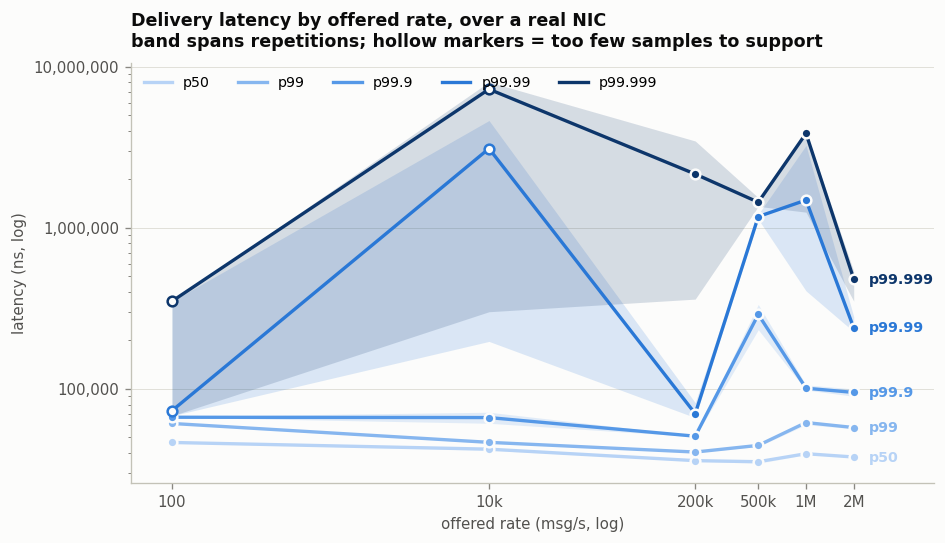

In [2]:
lvr = pd.read_csv(PLOTS / "latency_vs_rate.csv")
pcts = [("p50", "p50"), ("p99", "p99"), ("p99.9", "p99.9"),
        ("p99.99", "p99.99"), ("p99.999", "p99.999")]

fig, ax = plt.subplots(figsize=(8.0, 4.6))
for (col, label), colour in zip(pcts, [ORD6[0], ORD6[1], ORD6[2], ORD6[3], ORD6[5]]):
    ax.fill_between(lvr["rate"], lvr[f"{col}_lo"], lvr[f"{col}_hi"],
                    color=colour, alpha=0.16, linewidth=0, zorder=2)
    ax.plot(lvr["rate"], lvr[col], color=colour, label=label, zorder=3)
    # Solid where the sample count supports the percentile, hollow where it does not.
    if col in ("p99.99", "p99.999"):
        key = "p99.99_supported" if col == "p99.99" else "p99.999_supported"
        ok = lvr[key].fillna(0).astype(int) == 1
        ax.scatter(lvr["rate"][ok], lvr[col][ok], color=colour, s=34,
                   edgecolor=SURFACE, linewidth=1.5, zorder=4)
        ax.scatter(lvr["rate"][~ok], lvr[col][~ok], facecolor=SURFACE, s=34,
                   edgecolor=colour, linewidth=1.5, zorder=4)
    else:
        ax.scatter(lvr["rate"], lvr[col], color=colour, s=34,
                   edgecolor=SURFACE, linewidth=1.5, zorder=4)
    ax.annotate(label, (lvr["rate"].iloc[-1], lvr[col].iloc[-1]),
                textcoords="offset points", xytext=(9, 0), va="center",
                color=colour, fontsize=8.5, fontweight="600")

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_title("Delivery latency by offered rate, over a real NIC\n"
             "band spans repetitions; hollow markers = too few samples to support")
style(ax, ylabel="latency (ns, log)", xlabel="offered rate (msg/s, log)")
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(ns))
ax.set_xticks(lvr["rate"].tolist())
ax.set_xticklabels([rate_fmt(r) for r in lvr["rate"]])
ax.xaxis.set_minor_locator(mpl.ticker.NullLocator())
ax.set_xlim(lvr["rate"].min() * 0.55, lvr["rate"].max() * 3.2)
ax.legend(loc="upper left", ncols=5)
plt.tight_layout(); plt.show()

In [3]:
t = lvr[["rate", "samples", "min", "p50", "p99", "p99.9", "p99.99", "p99.999",
         "max", "drop_pct"]].copy()
t.columns = ["rate", "samples/run", "min", "p50", "p99", "p99.9", "p99.99",
             "p99.999", "max", "drop %"]
table(t.style.format({c: "{:,.0f}" for c in t.columns if c != "drop %"} |
                     {"drop %": "{:.4f}"}).hide(axis="index"),
      "Table 1 - latency in ns. p99.99 needs ~1M samples and p99.999 ~10M; "
      "the 100 and 10k rows do not have them and their far tail is not reported.")

Table 1 - latency in ns. p99.99 needs ~1M samples and p99.999 ~10M; the 100 and 10k rows do not have them and their far tail is not reported.


rate,samples/run,min,p50,p99,p99.9,p99.99,p99.999,max,drop %
100,"5,400","42,289","46,487","61,004","66,681","73,242","350,153","350,153",0.0000
"10,000","383,616","35,031","42,245","46,575","66,373","3,108,536","7,263,062","8,353,026",0.0000
"200,000","19,983,616","33,076","35,850","40,533","50,850","70,158","2,158,834","3,986,895",0.0000
"500,000","19,983,616","31,795","35,299","44,594","289,826","1,175,171","1,442,430","1,670,731",0.0000
"1,000,000","19,983,616","32,815","39,583","61,808","101,010","1,487,674","3,859,532","4,002,601",0.0088
"2,000,000","19,983,616","31,566","37,764","57,553","95,087","239,276","481,943","570,317",0.0000


## 2. Where the time actually goes

The sender stamps departure into the datagram header, the receiver stamps arrival and
publication, and joining on `seq_id` against the consumer's own timestamp gives the
fourth leg. Four legs, 20M messages, at 200k msg/s:

- **source ring + sender** — producer's stamp to the sender handing it to the kernel
- **wire** — kernel TX, NIC, cable, NIC RX, kernel RX
- **arrival → published** — receiver parsing and publishing into its ring
- **published → consumer** — the consumer's ring read

**What to look for:** the wire is everything. Our three legs together cost about
620 ns at the median out of 35 µs, and stay under 1 µs even at p99.999. There is no
optimisation left in our code that could matter at this scale -- the remaining lever
is the kernel network stack itself, which means kernel bypass.

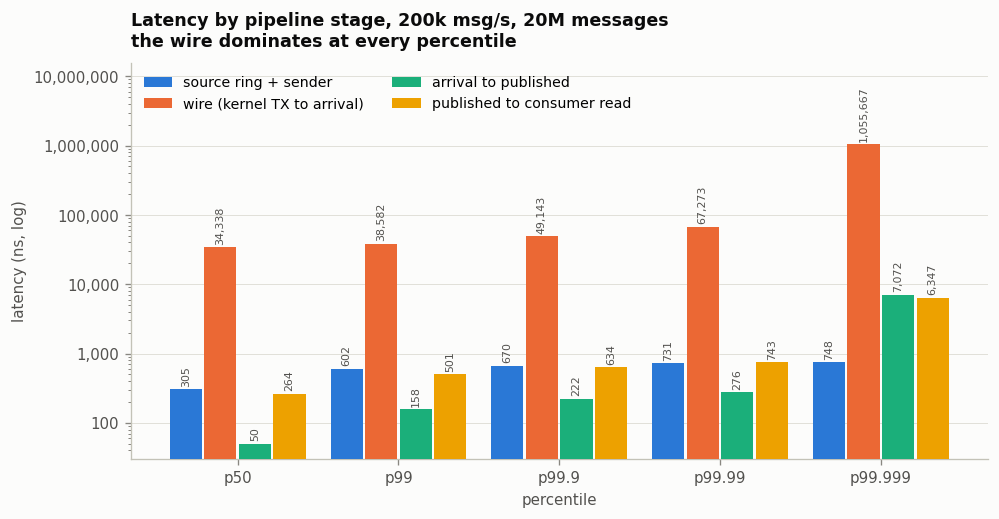

In [4]:
st = pd.read_csv(PLOTS / "stage_breakdown.csv")
legs = st[st["stage"] != "end to end"].reset_index(drop=True)
cols = ["p50", "p99", "p99.9", "p99.99", "p99.999"]
x = np.arange(len(cols))
w = 0.2

fig, ax = plt.subplots(figsize=(8.4, 4.4))
for i, row in legs.iterrows():
    vals = [row[c] for c in cols]
    off = (i - 1.5) * (w + 0.015)
    ax.bar(x + off, vals, width=w, color=CAT[i], label=row["stage"], zorder=3)
    # Direct labels: two of these fills are below 3:1 on this surface, so the
    # values must be readable without relying on colour.
    for xi, v in zip(x + off, vals):
        ax.annotate(f"{v:,.0f}", (xi, v), textcoords="offset points",
                    xytext=(0, 3), ha="center", color=INK2, fontsize=6.6,
                    rotation=90)
ax.set_yscale("log")
ax.set_xticks(x); ax.set_xticklabels(cols)
ax.set_ylim(top=ax.get_ylim()[1] * 9)
ax.set_title("Latency by pipeline stage, 200k msg/s, 20M messages\n"
             "the wire dominates at every percentile")
style(ax, ylabel="latency (ns, log)", xlabel="percentile")
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(ns))
ax.legend(loc="upper left", ncols=2)
plt.tight_layout(); plt.show()

In [5]:
t2 = st[["stage", "samples", "p50", "p99", "p99.9", "p99.99", "p99.999",
         "p99.9999", "max"]].copy()
table(t2.style.format({c: "{:,.0f}" for c in t2.columns if c != "stage"})
      .hide(axis="index"),
      "Table 2 - the three legs we control sum to ~620 ns at the median")

Table 2 - the three legs we control sum to ~620 ns at the median


stage,samples,p50,p99,p99.9,p99.99,p99.999,p99.9999,max
source ring + sender,"20,000,000",305,602,670,731,748,761,"4,777"
wire (kernel TX to arrival),"20,000,000","34,338","38,582","49,143","67,273","1,055,667","1,870,154","1,960,424"
arrival to published,"20,000,000",50,158,222,276,"7,072","9,984","12,984"
published to consumer read,"20,000,000",264,501,634,743,"6,347","25,090","108,465"
end to end,"20,000,000","34,996","39,268","49,818","68,089","1,056,468","1,870,948","1,961,160"


## 3. What a run actually looks like, and how outliers arrive

Percentiles hide time structure completely. This is latency against position in the
run, for three separate repetitions of the *same* configuration — the baseline
decimated to an even sample, plus every point above that repetition's p99.9 so no
outlier is lost to decimation.

**What to look for — this is a headline result, not a detail:** the baseline is a
tight band that barely moves, and **the spikes are not uniformly distributed. They
arrive in bursts.** Each tall vertical stripe is many consecutive messages late
together, which is what a queue draining looks like and not what independent random
stalls look like.

Grouping the messages above a threshold into runs of consecutive arrivals quantifies
it. Independent spikes would be almost entirely runs of length one. Instead:

| spike size | isolated occurrences | inside bursts of ≥10 messages |
|---|---|---|
| above 50 µs | ~23% | ~12% |
| above 100 µs | ~0.8% | ~92% |
| above 200 µs | ~0.1% | ~98% |
| **above 500 µs** | **0%** | **100%** |

The small excursions just past p99.9 are a mix, but **every large spike belongs to a
burst — not one isolated occurrence above 500 µs in any repetition.** A 20M-message
run contains only one to three such bursts, and they are what set p99.99 and beyond.

The bursts also differ completely between repetitions of an identical configuration —
2 ms in one run, 4.5 ms in another, only 700 µs in a third — which is why a single run
cannot establish a far-tail percentile, and why averaging them would describe
something that never happened.

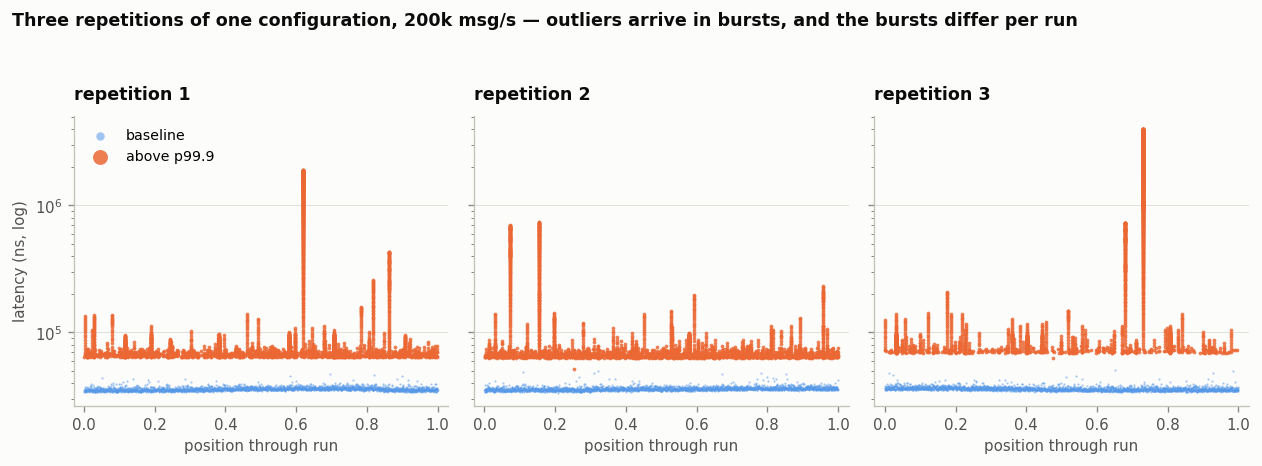

In [6]:
sc = pd.read_csv(PLOTS / "scatter_200k.csv")
reps = sorted(sc["rep"].unique())

fig, axes = plt.subplots(1, len(reps), figsize=(10.6, 3.9), sharey=True)
if len(reps) == 1:
    axes = [axes]
for ax, rep in zip(axes, reps):
    d = sc[sc["rep"] == rep]
    base, out = d[d["outlier"] == 0], d[d["outlier"] == 1]
    ax.scatter(base["fraction"], base["latency_ns"], s=1.6, color=ORD4[1],
               alpha=0.55, linewidth=0, zorder=3, label="baseline")
    ax.scatter(out["fraction"], out["latency_ns"], s=5.0, color=CAT[1],
               alpha=0.85, linewidth=0, zorder=4, label="above p99.9")
    ax.set_yscale("log")
    ax.set_title(f"repetition {rep}")
    style(ax, xlabel="position through run")
    ax.set_xlim(-0.03, 1.03)
    if ax is axes[0]:
        ax.set_ylabel("latency (ns, log)")
        ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(ns))
        ax.legend(loc="upper left", markerscale=4)
fig.suptitle("Three repetitions of one configuration, 200k msg/s — outliers arrive "
             "in bursts, and the bursts differ per run",
             x=0.012, ha="left", fontsize=10.5, fontweight="600", color=INK)
plt.tight_layout(rect=(0, 0, 1, 0.93)); plt.show()

In [7]:
bs = pd.read_csv(PLOTS / "burst_stats.csv")
show = bs[["threshold_ns", "rep", "messages", "bursts", "largest_burst",
           "singleton_pct", "in_bursts_ge10_pct"]].copy()
show.columns = ["spike >", "rep", "messages", "bursts", "largest burst",
                "isolated %", "in bursts >=10 %"]
table(show.style.format({"spike >": "{:,.0f}", "messages": "{:,.0f}",
                         "bursts": "{:,.0f}", "largest burst": "{:,.0f}",
                         "isolated %": "{:.2f}", "in bursts >=10 %": "{:.2f}"})
      .hide(axis="index"),
      "Table 3 - spikes grouped into runs of consecutive messages. Independent "
      "spikes would be almost all singletons; above 500 us there are none.")

Table 3 - spikes grouped into runs of consecutive messages. Independent spikes would be almost all singletons; above 500 us there are none.


spike >,rep,messages,bursts,largest burst,isolated %,in bursts >=10 %
"50,000",1,"22,483","10,456",471,23.09,11.77
"50,000",2,"21,643","10,263",177,23.37,8.44
"50,000",3,"23,569","10,615","1,147",23.02,15.67
"100,000",1,689,23,459,1.16,92.31
"100,000",2,514,26,165,0.58,89.11
"100,000",3,"1,488",37,"1,135",0.54,94.56
"200,000",1,523,3,436,0.00,100.00
"200,000",2,289,5,139,0.35,95.85
"200,000",3,"1,271",3,"1,113",0.00,99.76
"500,000",1,366,1,366,0.00,100.00


## 4. One outlier event, message by message

Taking the single worst message in the run and plotting its neighbours by sequence
id makes the mechanism unambiguous.

**What to look for:** a near-perfect straight line descending from ~2 ms, with each
consecutive message about 4.5 µs faster than the one before — and 4.5 µs is the
inter-message interval at this rate. That is a queue that stopped being served for
about 2 ms, accumulated several hundred messages, and then drained back-to-back. It
is one stall affecting many messages, not many independent stalls.

This is also why the far tail is so sensitive to run length: a single 2 ms event
contributes hundreds of samples to p99.99 and above.

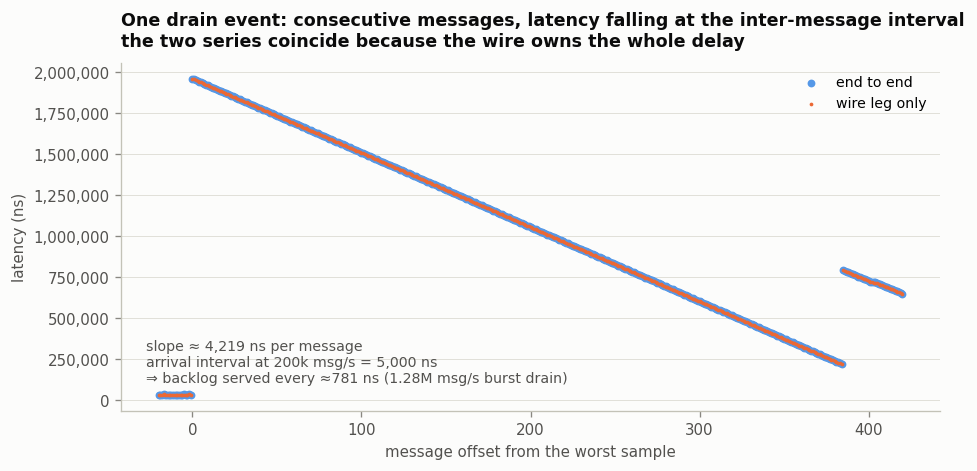

In [8]:
de = pd.read_csv(PLOTS / "drain_event.csv").sort_values("offset")

fig, ax = plt.subplots(figsize=(8.0, 4.0))
# End-to-end drawn larger and underneath, wire smaller on top: the two coincide, and
# this way the coincidence is visible as a blue halo instead of looking like a series
# that failed to plot.
ax.scatter(de["offset"], de["latency_ns"], s=22, color=ORD4[1], linewidth=0,
           zorder=3, label="end to end")
ax.scatter(de["offset"], de["wire_ns"], s=5, color=CAT[1], linewidth=0, zorder=4,
           label="wire leg only")
ax.set_title("One drain event: consecutive messages, latency falling at the "
             "inter-message interval\nthe two series coincide because the wire owns "
             "the whole delay")
style(ax, ylabel="latency (ns)", xlabel="message offset from the worst sample")
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(ns))
ax.legend(loc="upper right")
# Slope over the descending run, which should match the message interval.
tail = de[de["offset"] >= 0]
if len(tail) > 50:
    slope = np.polyfit(tail["offset"][:400], tail["latency_ns"][:400], 1)[0]
    # Drain interval implied by the slope: messages arrive every 5,000 ns and the
    # backlog shrinks by `slope` per message, so it is being served that much faster.
    drain = 5000 - abs(slope)
    ax.annotate(f"slope ≈ {abs(slope):,.0f} ns per message\n"
                f"arrival interval at 200k msg/s = 5,000 ns\n"
                f"⇒ backlog served every ≈{drain:,.0f} ns "
                f"({1e9/max(drain,1)/1e6:.2f}M msg/s burst drain)",
                xy=(0.03, 0.08), xycoords="axes fraction", color=INK2, fontsize=8.5)
plt.tight_layout(); plt.show()

In [9]:
oa = pd.read_csv(PLOTS / "outlier_attribution.csv")
table(oa.style.format(thousands=",").hide(axis="index"),
      "Table 4 - for every message over 1 ms, which leg was the largest")

Table 4 - for every message over 1 ms, which leg was the largest


leg,count,share_pct
wire_ns,213,100.000000


## 5. Tail curves

Latency against percentile, so the tail gets real width. Each step right is a 10x
rarer event.

**What to look for:** the curves are flat and tightly grouped out to about p99.9,
then bend sharply upward. The bend is the drain event of figure 4 entering the
distribution. Its position moves with rate only because the number of messages
caught inside a fixed-duration stall scales with rate.

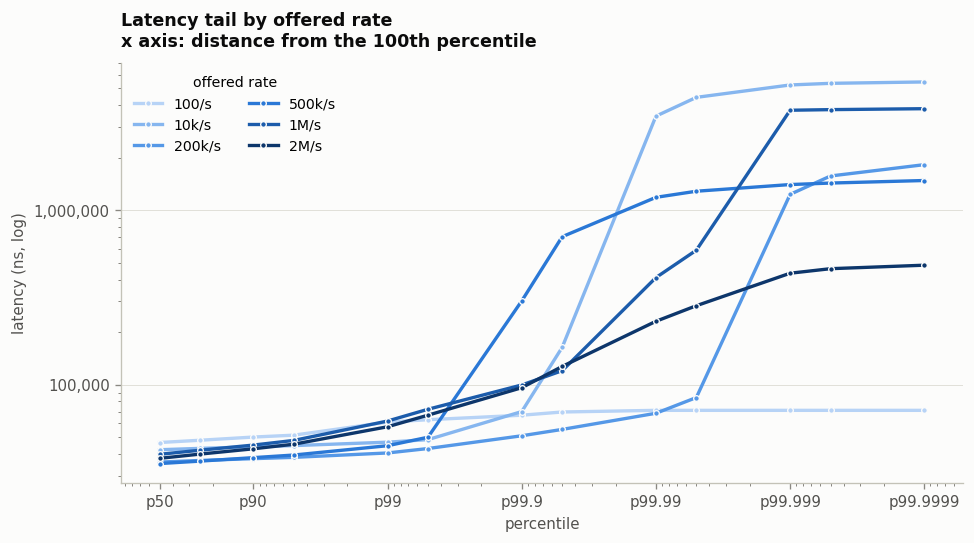

In [10]:
tails = pd.read_csv(PLOTS / "tail_curves.csv")
rates = sorted(tails["rate"].unique())

fig, ax = plt.subplots(figsize=(8.2, 4.6))
for rate, colour in zip(rates, ORD6):
    d = tails[tails["rate"] == rate].sort_values("percentile")
    ax.plot(100 - d["percentile"], d["latency_ns"], color=colour,
            label=rate_fmt(rate) + "/s", marker="o", markersize=3.4,
            markeredgecolor=SURFACE, markeredgewidth=0.8, zorder=3)
ax.set_xscale("log"); ax.set_yscale("log")
ax.invert_xaxis()
ax.set_title("Latency tail by offered rate\nx axis: distance from the 100th percentile")
style(ax, ylabel="latency (ns, log)", xlabel="percentile")
ticks = [50, 10, 1, 0.1, 0.01, 0.001, 0.0001]
ax.set_xticks(ticks); ax.set_xticklabels([f"p{100-t:g}" for t in ticks])
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(ns))
ax.legend(loc="upper left", title="offered rate", title_fontsize=8.5, ncols=2)
plt.tight_layout(); plt.show()

In [11]:
piv = tails.pivot(index="percentile", columns="rate", values="latency_ns")
piv.columns = [rate_fmt(c) + "/s" for c in piv.columns]
table(piv.style.format(thousands=",", na_rep="—"),
      "Table 5 - latency (ns) at each percentile, by offered rate")

Table 5 - latency (ns) at each percentile, by offered rate


,100/s,10k/s,200k/s,500k/s,1M/s,2M/s
percentile,,,,,,
50.000000,"46,470","42,249","35,876","35,180","39,768","37,696"
75.000000,"47,882","43,011","36,666","36,338","41,967","39,871"
90.000000,"49,953","43,919","37,549","38,061","44,933","42,770"
95.000000,"51,209","44,613","38,202","39,387","47,775","45,440"
99.000000,"60,880","46,685","40,479","44,549","61,730","57,227"
99.500000,"62,815","48,290","42,922","49,838","72,107","66,685"
99.900000,"66,660","69,952","50,804","301,926","99,418","95,886"
99.950000,"69,563","163,320","55,262","705,113","120,060","126,996"
99.990000,"71,097","3,469,682","68,409","1,186,432","410,964","230,643"


## 6. Shape of the bulk

The body of the distribution at 200k msg/s, clipped at p99.9 so it is visible at all.

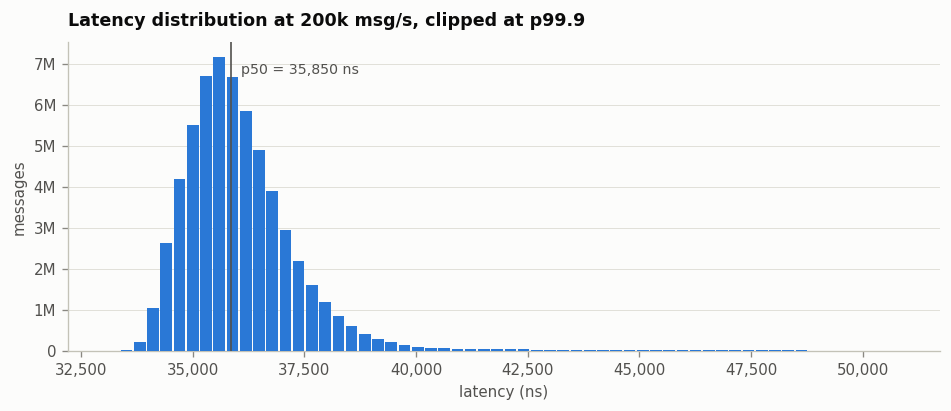

In [12]:
hist = pd.read_csv(PLOTS / "histogram_200000.csv")
mid = (hist["bin_low_ns"] + hist["bin_high_ns"]) / 2
width = (hist["bin_high_ns"] - hist["bin_low_ns"]) * 0.88

fig, ax = plt.subplots(figsize=(8.0, 3.5))
ax.bar(mid, hist["count"], width=width, color=ORD4[2], zorder=3)
p50 = int(lvr.loc[lvr["rate"] == 200000, "p50"].iloc[0])
ax.axvline(p50, color=INK2, lw=1, zorder=4)
ax.annotate(f"p50 = {p50:,} ns", xy=(p50, ax.get_ylim()[1] * 0.9),
            xytext=(6, 0), textcoords="offset points", color=INK2, fontsize=8.5)
ax.set_title("Latency distribution at 200k msg/s, clipped at p99.9")
style(ax, ylabel="messages", xlabel="latency (ns)")
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(ns))
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(
    lambda v, _: f"{v/1e6:g}M" if v >= 1e6 else (f"{v/1e3:g}k" if v >= 1e3 else f"{v:g}")))
plt.tight_layout(); plt.show()

## 7. Loss follows packet rate, not message rate

The expectation going in was that the NIC would start dropping as message rate climbed,
since it has a packets-per-second ceiling. It does not happen that way, and the reason is
batching.

**What to look for:** the only loss in the entire sweep is 0.0088% at 1M msg/s --
and 1M is where *packets* per second peak, at 840k. At 2M msg/s the sender is packing
2.5 messages per datagram, so packets per second fall to 790k and loss returns to
zero. Message rate doubles while packet rate drops, and so does loss.

So the packets-per-second limit is real and we are near it; batching is what keeps
the higher message rates on the safe side of it. That is also the mechanism that
would break first if messages were larger or batching were disabled.

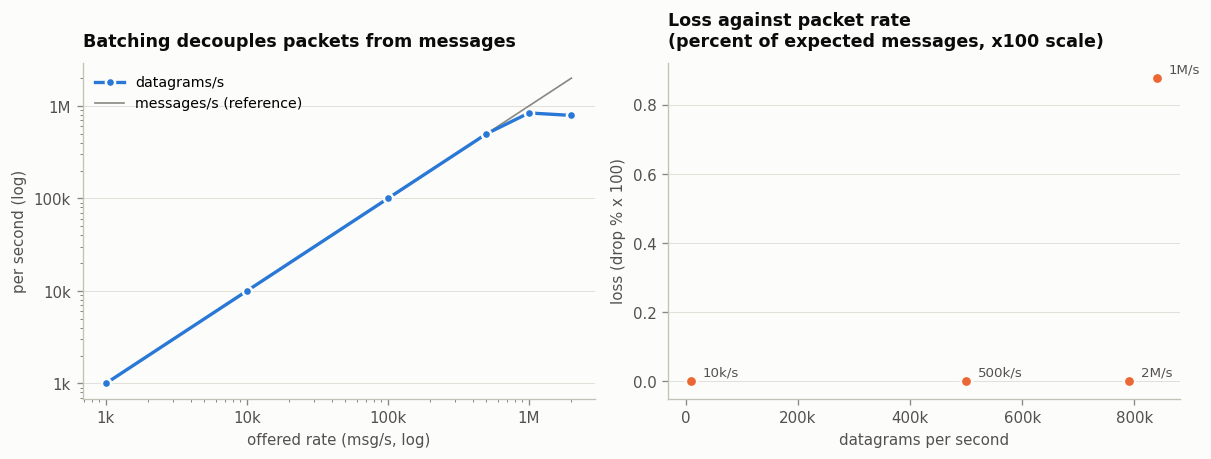

In [13]:
ad = pd.read_csv(PLOTS / "adaptive_redundancy.csv").sort_values("rate")
ad["datagrams_per_s"] = (ad["rate"] / ad["frames_per_datagram"]).round(0)
loss = lvr[["rate", "drop_pct"]]
ad = ad.merge(loss, on="rate", how="left")

fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.9))

ax = axes[0]
ax.plot(ad["rate"], ad["datagrams_per_s"], color=ORD4[2], marker="o",
        markeredgecolor=SURFACE, markeredgewidth=1.5, zorder=3, label="datagrams/s")
ax.plot(ad["rate"], ad["rate"], color=MUTED, lw=1, ls="-", zorder=2,
        label="messages/s (reference)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_title("Batching decouples packets from messages")
style(ax, ylabel="per second (log)", xlabel="offered rate (msg/s, log)")
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(rate_fmt))
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(rate_fmt))
ax.legend(loc="upper left")

ax = axes[1]
d = ad.dropna(subset=["drop_pct"])
ax.scatter(d["datagrams_per_s"], d["drop_pct"] * 100, s=46, color=CAT[1],
           edgecolor=SURFACE, linewidth=1.5, zorder=3)
for _, r in d.iterrows():
    ax.annotate(rate_fmt(r["rate"]) + "/s",
                (r["datagrams_per_s"], r["drop_pct"] * 100),
                textcoords="offset points", xytext=(7, 3), color=INK2, fontsize=8)
ax.set_title("Loss against packet rate\n(percent of expected messages, x100 scale)")
style(ax, ylabel="loss (drop % x 100)", xlabel="datagrams per second")
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(rate_fmt))
ax.set_ylim(bottom=-0.05)
plt.tight_layout(); plt.show()

In [14]:
t7 = ad[["rate", "frames_per_datagram", "datagrams_per_s", "duplication_pct",
         "drop_pct"]].copy()
t7.columns = ["msg/s", "msgs per datagram", "datagrams/s", "duplication %", "drop %"]
table(t7.style.format({"msg/s": "{:,.0f}", "datagrams/s": "{:,.0f}",
                       "drop %": "{:.4f}"}).hide(axis="index"),
      "Table 7 - the only loss sits at the highest packet rate, not the highest "
      "message rate")

Table 7 - the only loss sits at the highest packet rate, not the highest message rate


msg/s,msgs per datagram,datagrams/s,duplication %,drop %
"1,000",1.000000,"1,000",100.000000,nan
"10,000",1.000000,"10,000",100.000000,0.0000
"100,000",1.000000,"100,000",100.000000,nan
"500,000",1.000000,"500,000",77.700000,0.0000
"1,000,000",1.190000,"840,336",0.400000,0.0088
"2,000,000",2.530000,"790,514",0.000000,0.0000


## 7b. What redundancy actually bought

Duplication was designed against independent loss, where sending everything twice turns
loss probability p into p². That is only as good as the independence assumption.

**First, how much loss there is at all.** Across the sweep with redundancy disabled — 241
million messages — the table below is the entire loss budget. Four of six rates lost
nothing whatsoever, and the only loss sits at the highest packet rate. Nothing approaches
the 0.01%–1% the task treats as realistic, so **this path cannot exercise a loss-recovery
mechanism**. That is a property of the environment, not a claim about the design.

**Second, the loss that does occur is bursty**: 485 lost datagrams arrived in **7 events**,
about 69 consecutive datagrams each.

**What to look for:** the rescue column. A redundant copy follows its original by
microseconds, so it lands inside the same burst and dies with it — 2 rescues out of 485.
Duplication as implemented is nearly useless against the loss this path actually exhibits,
and the p → p² argument does not apply because its independence premise is false here. The
fix it points to is a temporal stagger — hold the copy back by longer than a burst — which
is not implemented because with 2 × 10⁻⁵ loss there is nothing to measure it against.

In [15]:
loss = pd.read_csv(PLOTS / "loss_summary.csv")
t = loss.copy()
t["loss fraction"] = t["dropped"] / t["expected"]
t = t[["rate", "received", "dropped", "loss fraction"]]
t.columns = ["offered rate", "messages", "lost", "loss fraction"]
table(t.style.format({"offered rate": "{:,.0f}", "messages": "{:,.0f}",
                      "lost": "{:,.0f}", "loss fraction": "{:.2e}"}).hide(axis="index"),
      "Table 7b-1 - the entire loss budget of the sweep: 5,262 of 241 million messages")

Table 7b-1 - the entire loss budget of the sweep: 5,262 of 241 million messages


offered rate,messages,lost,loss fraction
100,"16,200",0,0.00e+00
"10,000","1,150,848",0,0.00e+00
"200,000","59,950,848",0,0.00e+00
"500,000","59,950,848",0,0.00e+00
"1,000,000","59,950,848","5,262",8.78e-05
"2,000,000","59,950,848",0,0.00e+00


In [16]:
bl = pd.read_csv(PLOTS / "burst_loss.csv")
t = bl.copy()
t.columns = ["rate", "duplication %", "gap events", "datagrams lost", "per event",
             "rescued by a copy", "rescue %"]
table(t.style.format({"rate": "{:,.0f}", "datagrams lost": "{:,.0f}"}).hide(axis="index"),
      "Table 7b-2 - loss arrives in bursts, and a copy sent microseconds later shares "
      "their fate")

Table 7b-2 - loss arrives in bursts, and a copy sent microseconds later shares their fate


rate,duplication %,gap events,datagrams lost,per event,rescued by a copy,rescue %
"500,000",77.700000,7,485,69.300000,2,0.410000
"1,000,000",0.400000,50,"4,007",80.100000,14,0.350000


## 8. Fan-out to N independent receivers

Each receiver is a separate process with its own socket, its own shared-memory ring
and its own consumer, and the sender transmits a **separate datagram to each**:

```
sender -+- datagram -> receiver 1 -> shm 1 -> consumer 1
        +- datagram -> receiver 2 -> shm 2 -> consumer 2
        +- datagram -> receiver 3 -> shm 3 -> consumer 3
```

Redundancy is disabled for this sweep so receiver count is the only variable. With it
enabled the comparison is confounded: at one receiver there is spare capacity so
duplication runs near 100% and that receiver handles twice the datagrams, while at
three receivers the sender spends its idle time on the extra destinations instead.

**What to look for:** skew grows cleanly with N — about 1.3 µs per additional receiver,
reaching 11.7 µs at ten. The medians rise too, roughly 15 µs from one receiver to ten,
though they do not order cleanly between two and three where the difference is smaller
than the burst events of figure 4.

**The third panel is the finding that matters.** Each receiver costs one more packet per
datagram, so N receivers multiply packet rate by N against a ceiling this path puts at
about 840k datagrams per second. At ten receivers and 500k msg/s the sender was already at
**97% of that ceiling**. The ceiling therefore divides the achievable message rate by
receiver count, and no optimisation above the socket layer changes it — at 50 receivers the
budget allows on the order of 100k msg/s, twenty times below the task's top rate.

Reaching 50 receivers means not sending N copies from one host: network-level multicast,
where packet rate stops depending on N, or a relay tree where each tier fans out to a
bounded number of children at the cost of a hop. Neither is implemented; these
measurements are the argument for why one is necessary.

The receivers also share one host here, so a single NIC carries N copies where N separate
hosts would each carry one.

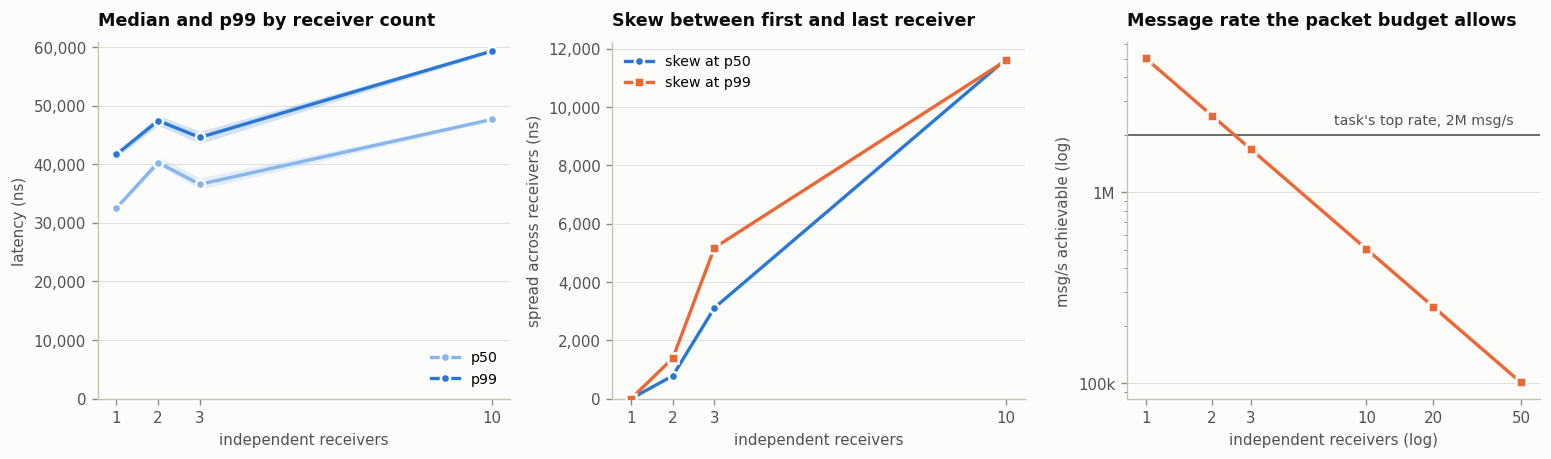

In [17]:
fan = pd.read_csv(PLOTS / "fanout.csv").sort_values("receivers")

budget = pd.read_csv(PLOTS / "pps_budget.csv")
fig, axes = plt.subplots(1, 3, figsize=(13.0, 3.9))

ax = axes[0]
for (col, label), colour in zip(pcts[:2], (ORD4[0], ORD4[2])):
    ax.fill_between(fan["receivers"], fan[f"{col}_lo"], fan[f"{col}_hi"],
                    color=colour, alpha=0.20, linewidth=0, zorder=2)
    ax.plot(fan["receivers"], fan[col], color=colour, label=label, marker="o",
            markeredgecolor=SURFACE, markeredgewidth=1.5, zorder=3)
ax.set_xticks(fan["receivers"]); ax.set_ylim(bottom=0)
ax.set_title("Median and p99 by receiver count")
style(ax, ylabel="latency (ns)", xlabel="independent receivers")
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(ns))
ax.legend(loc="lower right")

ax = axes[1]
ax.plot(fan["receivers"], fan["skew_p50"], color=ORD4[2], marker="o",
        markeredgecolor=SURFACE, markeredgewidth=1.5, label="skew at p50", zorder=3)
ax.plot(fan["receivers"], fan["skew_p99"], color=CAT[1], marker="s",
        markeredgecolor=SURFACE, markeredgewidth=1.5, label="skew at p99", zorder=3)
ax.set_xticks(fan["receivers"]); ax.set_ylim(bottom=0)
ax.set_title("Skew between first and last receiver")
style(ax, ylabel="spread across receivers (ns)", xlabel="independent receivers")
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(ns))
ax.legend(loc="upper left")

# The binding limit: each receiver costs another packet, so the measured pps ceiling
# divides the achievable message rate. Arithmetic on a measured ceiling, not a fit.
ax = axes[2]
ax.plot(budget["receivers"], budget["message_rate"], color=CAT[1], marker="s",
        markeredgecolor=SURFACE, markeredgewidth=1.5, zorder=3)
ax.axhline(2_000_000, color=INK2, lw=1, zorder=2)
ax.annotate("task's top rate, 2M msg/s", xy=(budget["receivers"].iloc[-1], 2_000_000),
            xytext=(-4, 6), textcoords="offset points", ha="right", color=INK2,
            fontsize=8.5)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xticks(budget["receivers"].tolist())
ax.set_xticklabels(budget["receivers"].tolist())
ax.xaxis.set_minor_locator(mpl.ticker.NullLocator())
ax.set_title("Message rate the packet budget allows")
style(ax, ylabel="msg/s achievable (log)", xlabel="independent receivers (log)")
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(rate_fmt))
plt.tight_layout(); plt.show()

In [18]:
t8 = fan[["receivers", "samples", "p50", "p99", "p99.9", "p99.99",
          "skew_p50", "skew_p99"]].copy()
t8.columns = ["receivers", "samples/run", "p50", "p99", "p99.9", "p99.99",
              "skew p50", "skew p99"]
table(t8.style.format(thousands=",").hide(axis="index"),
      "Table 8 - skew is the clean signal; the medians are within drain-event noise")

Table 8 - skew is the clean signal; the medians are within drain-event noise


receivers,samples/run,p50,p99,p99.9,p99.99,skew p50,skew p99
1,"9,983,616","32,569","41,701","246,853","962,770",0,0
2,"9,983,616","40,295","47,449","63,858","703,127",783,"1,385"
3,"9,983,616","36,585","44,593","56,706","697,663","3,116","5,178"
10,"3,983,616","47,663","59,322","65,871","323,756","11,646","11,601"


## 9. How to put one datagram on N destinations

Three ways, all implemented and measured at **ten destinations** and 200k msg/s — a rate
none of them saturates, so the result reflects per-call cost rather than which one runs out
of headroom first.

One API constraint rules out an obvious hybrid: `sendmmsg` takes **one socket** plus an
array of messages, not an array of sockets. You cannot `connect()` several sockets and then
reach them all in a single `sendmmsg` — N destinations need either N `msg_name`s on one
unconnected socket, or N separate sockets.

| method | syscalls per datagram | destination resolution |
|---|---|---|
| `sendmmsg` | 1 | per message, in-kernel |
| `sendto` x N | N | per call |
| connected sockets, `send` x N | N | once, at `connect()` |

**What to look for:** connected sockets win — 47.8 µs at the median against 52.3 and 50.5,
with the lowest skew between destinations.

**The per-stage split identifies the mechanism, and it is not the obvious one.** The wire
leg is the same for all three within 5% (34.2–36.0 µs). The whole difference sits in the
**source-ring leg** — how long a message waits before the sender reaches it: 5.8 µs for
connected against 8.2 for the others. A cheaper send call drains the ring faster, so less
queues up and fewer messages accumulate per datagram (2.27 against 3.16). End-to-end
latency follows from sender throughput, not from anything happening on the wire.

A tempting explanation is the kernel resolving each
destination per `sendmmsg` element while `connect()` resolves once. **That explanation was
wrong** — a route lookup is 100–200 ns and cannot account for a 4.6 µs difference. It also
rested on a same-host comparison, which cannot separate send mechanisms at all.

Also worth stating: **`sendto` × 10 could not sustain 1M msg/s at ten destinations at all**
— a workload the other two finish in about 4 seconds had not completed after 12 minutes. It
is ruled out on throughput, not only latency. And the structural argument that one syscall
must beat N has now lost at both 3 and 10 destinations.

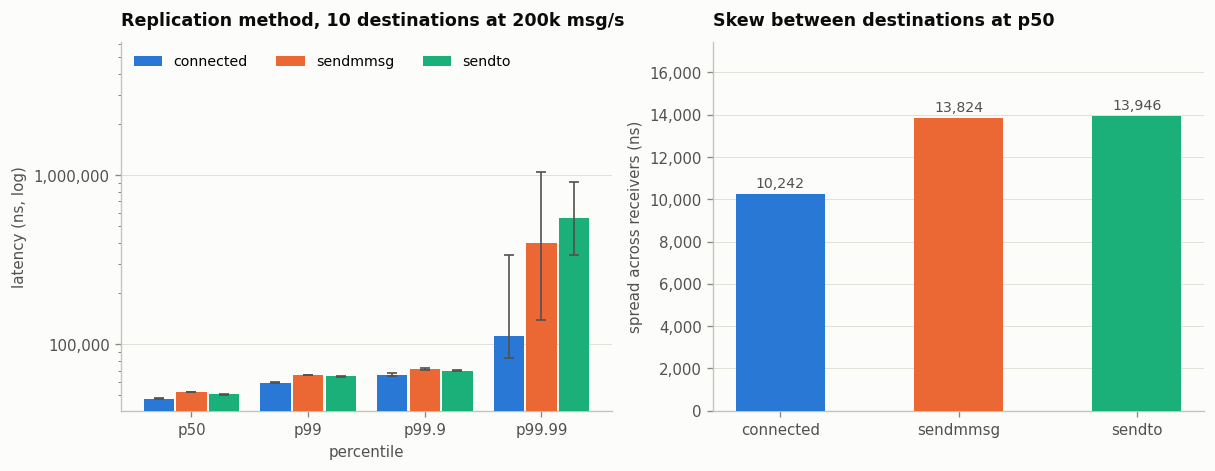

In [19]:
meth = pd.read_csv(PLOTS / "send_methods.csv")
order = ["connected", "sendmmsg", "sendto"]
meth = meth.set_index("method").loc[[m for m in order if m in set(meth["method"])]].reset_index()
cols4 = ["p50", "p99", "p99.9", "p99.99"]
x = np.arange(len(cols4)); w = 0.26

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.0))
ax = axes[0]
for i, (_, row) in enumerate(meth.iterrows()):
    vals = np.array([row[c] for c in cols4], float)
    lo = np.array([row[f"{c}_lo"] for c in cols4], float)
    hi = np.array([row[f"{c}_hi"] for c in cols4], float)
    off = (i - 1) * (w + 0.02)
    ax.bar(x + off, vals, width=w, color=CAT[i], label=row["method"], zorder=3)
    ax.errorbar(x + off, vals, yerr=[vals - lo, hi - vals], fmt="none",
                ecolor=INK2, elinewidth=1, capsize=3, zorder=4)
ax.set_yscale("log")
ax.set_xticks(x); ax.set_xticklabels(cols4)
ax.set_ylim(top=ax.get_ylim()[1] * 5)
ax.set_title("Replication method, 10 destinations at 200k msg/s")
style(ax, ylabel="latency (ns, log)", xlabel="percentile")
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(ns))
ax.legend(loc="upper left", ncols=3)

ax = axes[1]
ax.bar(np.arange(len(meth)), meth["skew_p50"], width=0.5,
       color=[CAT[i] for i in range(len(meth))], zorder=3)
for i, v in enumerate(meth["skew_p50"]):
    ax.annotate(f"{v:,.0f}", (i, v), textcoords="offset points", xytext=(0, 4),
                ha="center", color=INK2, fontsize=8.5)
ax.set_xticks(np.arange(len(meth))); ax.set_xticklabels(meth["method"])
ax.set_ylim(bottom=0, top=meth["skew_p50"].max() * 1.25)
ax.set_title("Skew between destinations at p50")
style(ax, ylabel="spread across receivers (ns)")
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(ns))
plt.tight_layout(); plt.show()

In [20]:
t9 = meth[["method", "p50", "p50_lo", "p50_hi", "p99", "p99.9", "skew_p50"]].copy()
t9.columns = ["method", "p50", "p50 lo", "p50 hi", "p99", "p99.9", "skew p50"]
table(t9.style.format(thousands=",").hide(axis="index"),
      "Table 9 - connected sockets, on both median and skew")

Table 9 - connected sockets, on both median and skew


method,p50,p50 lo,p50 hi,p99,p99.9,skew p50
connected,"47,764","47,314","48,413","59,451","66,215","10,242"
sendmmsg,"52,328","52,133","52,521","65,822","71,189","13,824"
sendto,"50,533","50,087","50,760","64,794","69,895","13,946"


## 9b. io_uring against kernel UDP

Section 9 established that send cost is the lever: the wire leg is the same whatever call
places the datagram on it, and the whole difference between replication methods shows up
as time waiting in the source ring. io_uring is the cheapest way to cut that cost — no
privileges, no dedicated NIC queue, no reserved memory. The arithmetic being tested is
just the call count for reaching N destinations: **N** for kernel UDP, **one** for io_uring,
**zero** with a submission-queue poll thread.

Because the backend is selectable at each end independently, the send and receive paths
are separated rather than confounded. That matters, because they give opposite answers.

**One statistical note first, because it decides what can be claimed.** The natural
summary — the median across the thirty per-receiver files — is the wrong tool here. At
p99.99 it spreads from 70 µs to 15 ms *for every configuration*, because each file's
p99.99 is really asking whether that receiver caught a drain event. So the figure below
plots the **per-repetition pooled** percentile: the ten receivers combined within each
repetition, one point per repetition, each backed by ~40M samples. Three points per
backend, plotted rather than averaged, because overlap is the finding wherever it appears.

**What to look for, and what not to conclude.** On the left, io_uring's three points sit
below kernel UDP's at **p50** and overlap at **p99 and p99.9**; at **p99.99** nothing
separates, because within one backend the points span a factor of seven. Comparing the
p99.99 medians alone would suggest a 65% gain — an artifact of the summary statistic, not
claimed.

The p50 separation does not survive either, and section 9c is about why: measuring the same
two configurations in a later session **reversed the sign**. Three tight repetitions inside
one session are not three independent samples. Nothing on the left panel is claimed as a
resolved end-to-end difference.

On the right, the io_uring *receive* path is decisively worse and nowhere near overlapping
— a factor of 1.7 at the median, far larger than session drift, and it drops datagrams
where the kernel path drops none. That much is arithmetic: both shapes already cost one
transition per datagram on this side, so there was never a call to save, only bookkeeping
to add. The *size* of the penalty is larger than bookkeeping explains and is left open.

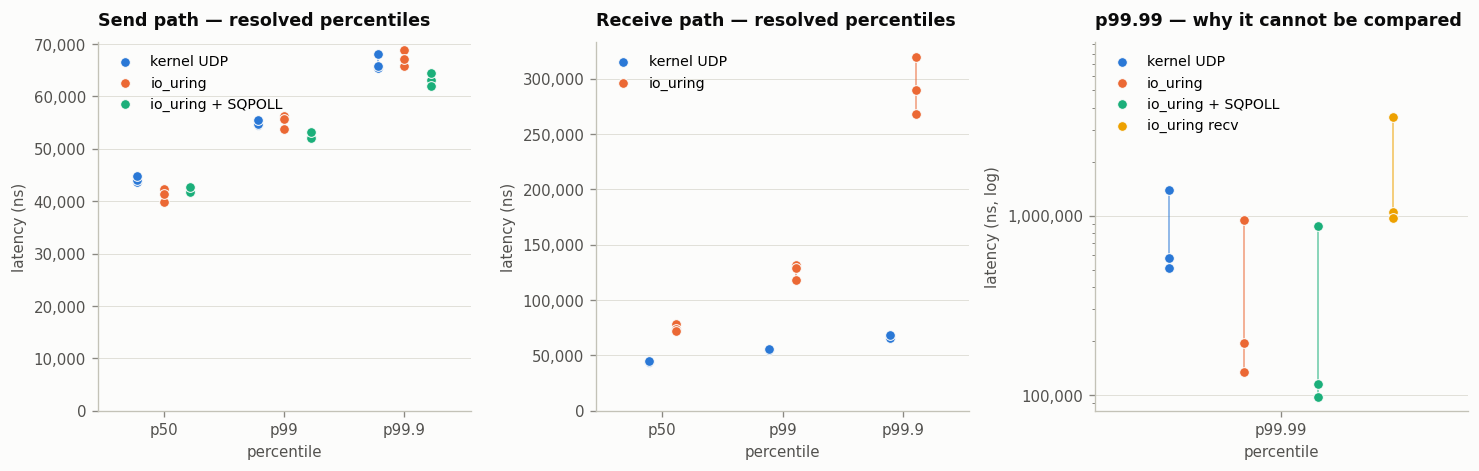

In [21]:
reps = pd.read_csv(PLOTS / "backend_reps.csv")
SEND = [("udp+udp", "kernel UDP"), ("iouring+udp", "io_uring"),
        ("sqpoll+udp", "io_uring + SQPOLL")]
RECV = [("udp+udp", "kernel UDP"), ("udp+iouring", "io_uring")]


def strip(ax, groups, cols, title, log=False):
    'One marker per repetition; the hairline is that group''s own spread.'
    x = np.arange(len(cols))
    for i, (k, lab) in enumerate(groups):
        g = reps[reps["config"] == k]
        if g.empty:
            continue
        off = (i - (len(groups) - 1) / 2) * 0.22
        for c, xi in zip(cols, x):
            ax.plot([xi + off, xi + off], [g[c].min(), g[c].max()],
                    color=CAT[i], linewidth=1.2, alpha=0.5, zorder=2)
            ax.scatter(np.full(len(g), xi + off), g[c], s=34, color=CAT[i], zorder=3,
                       label=lab if c == cols[0] else None,
                       edgecolor=SURFACE, linewidth=0.6)
    if log:
        ax.set_yscale("log")
        ax.set_ylim(top=ax.get_ylim()[1] * 2.2)
    else:
        ax.set_ylim(bottom=0)
    ax.set_xticks(x); ax.set_xticklabels(cols)
    ax.set_xlim(-0.55, len(cols) - 0.45)
    ax.set_title(title)
    style(ax, ylabel="latency (ns" + (", log)" if log else ")"), xlabel="percentile")
    ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(ns))
    ax.legend(loc="upper left")


RESOLVED = ["p50", "p99", "p99.9"]
fig, axes = plt.subplots(1, 3, figsize=(12.4, 4.0))
strip(axes[0], SEND, RESOLVED, "Send path — resolved percentiles")
strip(axes[1], RECV, RESOLVED, "Receive path — resolved percentiles")
strip(axes[2], SEND + [("udp+iouring", "io_uring recv")], ["p99.99"],
      "p99.99 — why it cannot be compared", log=True)
plt.tight_layout(); plt.show()

In [22]:
t9b = reps.pivot_table(index="config", columns="rep",
                       values=["p50", "p99", "p99.9", "p99.99"])
t9b = t9b.reorder_levels([0, 1], axis=1).sort_index(axis=1)
order = ["udp+udp", "iouring+udp", "sqpoll+udp", "udp+iouring", "iouring+iouring"]
t9b = t9b.loc[[c for c in order if c in t9b.index]]
table(t9b.style.format("{:,.0f}"),
      "Table 9b - per-repetition pooled percentiles, 10 destinations at 200k msg/s, "
      "redundancy off, ~40M samples per value")

Table 9b - per-repetition pooled percentiles, 10 destinations at 200k msg/s, redundancy off, ~40M samples per value


In [23]:
drops = pd.read_csv(PLOTS / "backends.csv")[["config", "send", "recv", "drop_pct"]]
drops.columns = ["config", "send", "receive", "drops %"]
table(drops.style.hide(axis="index"),
      "Table 9b2 - drops by configuration. The io_uring receive path loses datagrams "
      "where the kernel path loses none, which is reported beside the latency rather "
      "than under it.")

Table 9b2 - drops by configuration. The io_uring receive path loses datagrams where the kernel path loses none, which is reported beside the latency rather than under it.


config,send,receive,drops %
udp+udp,udp,udp,0.000000
iouring+udp,iouring,udp,0.000000
sqpoll+udp,iouring-sqpoll,udp,0.004082
udp+iouring,udp,iouring,0.000792
iouring+iouring,iouring,iouring,0.007335


### Does the send advantage scale with destination count?

It should, since the saving is N calls against one. Held at 500k msg/s with redundancy
off, across one to ten independent receivers.

**What to look for:** at **one** destination io_uring is slightly *worse* at the median —
one connected `send()` and one submission are the same single transition into the kernel,
so there is no call to save and only bookkeeping to add. A mechanism claiming to win there
would be one to distrust. But io_uring is better at **p99.9 and p99.99 at every
destination count**, and the **skew between destinations falls at every fan-out** — one
submission carrying all N puts them on the wire closer together than N separate calls can.
Since latency is measured at every receiver, that skew is part of the tail being judged.

The median and p99 differences at two or more destinations are a few percent, at or below
the run-to-run variation this setup shows across receiver counts, and are not claimed as a
resolved win. p99.999 is omitted because 2M samples per repetition does not support it.

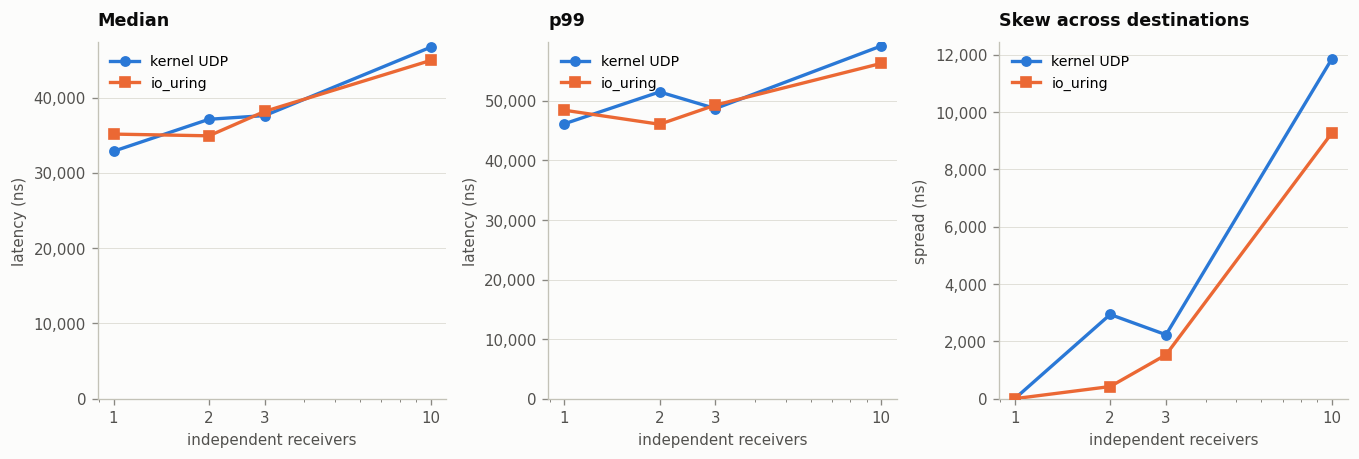

In [24]:
bf = pd.read_csv(PLOTS / "backend_fanout.csv")
# p50, p99 and skew only. The tail percentiles at this sample size swing by an order
# of magnitude between adjacent receiver counts, and plotting them would invite exactly
# the reading the text above withdraws.
panels = [("p50", "Median"), ("p99", "p99"), ("skew_p50", "Skew across destinations")]
fig, axes = plt.subplots(1, 3, figsize=(11.4, 3.9))
for ax, (col, title) in zip(axes, panels):
    for i, (name, lab) in enumerate((("udp", "kernel UDP"), ("iouring", "io_uring"))):
        g = bf[bf["backend"] == name].sort_values("receivers")
        if g.empty:
            continue
        ax.plot(g["receivers"], g[col], marker="o" if i == 0 else "s",
                color=CAT[i], label=lab, zorder=3)
    ax.set_xscale("log"); ax.set_xticks(sorted(bf["receivers"].unique()))
    ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f"{v:g}"))
    ax.set_ylim(bottom=0)
    ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(ns))
    ax.set_title(title)
    style(ax, ylabel="latency (ns)" if col != "skew_p50" else "spread (ns)",
          xlabel="independent receivers")
    ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

In [25]:
piv = bf.pivot_table(index="receivers", columns="backend",
                     values=["p50", "p99", "p99.9", "p99.99", "skew_p50"])
piv = piv.reorder_levels([1, 0], axis=1).sort_index(axis=1)
table(piv.style.format("{:,.0f}"),
      "Table 9c - fan-out sweep at 500k msg/s, redundancy off, both backends")

Table 9c - fan-out sweep at 500k msg/s, redundancy off, both backends


**SQPOLL is measured but not recommended.** Removing the last system call gives the best
p99.99 of any configuration — 98.7 µs against 132.3 µs for plain io_uring — but it burns a
dedicated core spinning, and in the run above **two of ten receivers dropped about 1,123
datagrams each in two burst events, confined to one of three repetitions**, while kernel
UDP and plain io_uring both dropped exactly zero under identical conditions. One
occurrence is not proof of causation, but it is not a trade to accept on a single
favourable measurement either.

**What ships:** the kernel-UDP path at both ends stays the default, with `--backend
iouring` selecting the io_uring sender. Every rate, fan-out and loss figure elsewhere in
this notebook was measured on the kernel-UDP path, so promoting a new default without
re-running that sweep would leave the results describing a configuration no longer
shipped. On this evidence the send path should become io_uring for any fan-out of two or
more, and what remains is that re-run rather than more design.

## 9c. AF_XDP, and why the medians could not settle it

A third send mechanism: AF_XDP writes a complete Ethernet frame into memory the driver
reads from, skipping the kernel's IP and UDP layers, its routing lookup, its netfilter
hooks and its queueing discipline. The relay builds those headers itself.

**It could not test what it was chosen for.** This NIC implements XDP but has no AF_XDP
zero-copy support — no xsk pool operations in the driver, and `XDP_ZEROCOPY` binds are
refused. Only copy mode is available, and copy-mode transmit still allocates an skb and
goes through `dev_direct_xmit`. So it removes the protocol stack but keeps most of the
kernel involvement, which is precisely what needed ruling out. That limitation was written
into the backend's header comment *before* measuring, together with the prediction that it
might therefore be slower than a plain `send()`.

### First: the end-to-end medians are not usable here

Running three repetitions of one backend and then three of the next confounds backend with
time. Measuring the same two configurations again in a later session showed how badly —
**the sign reversed, and the reversal was the same size as the effect**:

| | kernel UDP p50 | io_uring p50 | difference |
|---|---|---|---|
| session 1 | 43,754 / 43,965 / 44,717 | 39,869 / 41,306 / 42,246 | −3,005 ns |
| session 2 | 41,147 / 41,390 / 41,442 | 43,583 / 44,361 / 44,762 | +2,909 ns |

Within either session the repetitions are tight and non-overlapping, which is exactly what
makes this trap dangerous. So the two figures below use measurements that do not depend on
a cross-host clock or a comparison between sessions.

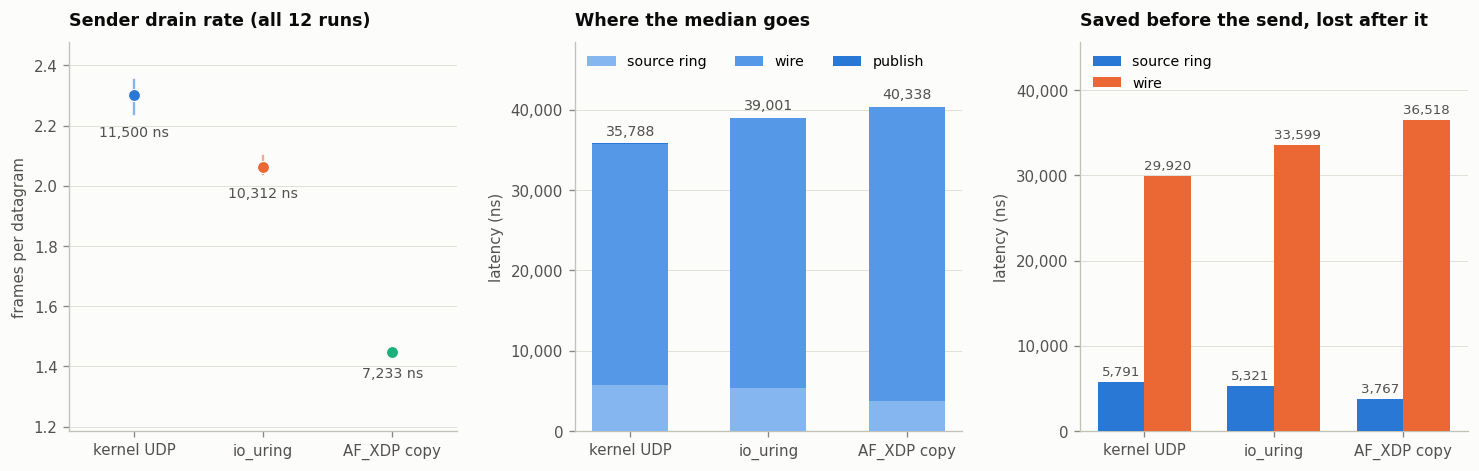

In [26]:
drain = pd.read_csv(PLOTS / "send_backend_drain.csv")
stg = pd.read_csv(PLOTS / "send_backend_stages.csv")
ORDER = ["kernel-udp", "io_uring", "afxdp-copy"]
LABEL = {"kernel-udp": "kernel UDP", "io_uring": "io_uring", "afxdp-copy": "AF_XDP copy"}
drain = drain.set_index("backend").loc[[b for b in ORDER if b in set(drain["backend"])]]
stg = stg.set_index("backend").loc[[b for b in ORDER if b in set(stg["backend"])]]

fig, axes = plt.subplots(1, 3, figsize=(12.4, 4.0))

# 1. drain rate: every run, so the reproducibility is visible rather than asserted
ax = axes[0]
for i, b in enumerate(drain.index):
    r = drain.loc[b]
    ax.plot([i, i], [r["frames_per_datagram_min"], r["frames_per_datagram_max"]],
            color=CAT[i], linewidth=1.4, alpha=0.55, zorder=2)
    ax.scatter([i], [r["frames_per_datagram_mean"]], s=52, color=CAT[i], zorder=3,
               edgecolor=SURFACE, linewidth=0.7)
    ax.annotate(f"{r['send_cycle_ns']:,.0f} ns", (i, r["frames_per_datagram_min"]),
                textcoords="offset points", xytext=(0, -14), ha="center",
                color=INK2, fontsize=8.5)
ax.set_xticks(range(len(drain))); ax.set_xticklabels([LABEL[b] for b in drain.index])
# Zoomed to the data, not to zero: the point of this panel is that the run-to-run
# spread is far smaller than the gap between mechanisms, and a zero baseline hides it.
lo = drain["frames_per_datagram_min"].min()
hi = drain["frames_per_datagram_max"].max()
pad = (hi - lo) * 0.28
ax.set_ylim(lo - pad, hi + pad * 0.5)
ax.set_xlim(-0.5, len(drain) - 0.5)
ax.set_title("Sender drain rate (all 12 runs)")
style(ax, ylabel="frames per datagram", xlabel="")

# 2. where the time goes
ax = axes[1]
legs = [("shm_p50", "source ring"), ("wire_p50", "wire"), ("publish_p50", "publish")]
bottom = np.zeros(len(stg))
for j, (col, name) in enumerate(legs):
    vals = stg[col].to_numpy(float)
    ax.bar(np.arange(len(stg)), vals, bottom=bottom, width=0.55,
           color=ORD4[j], label=name, zorder=3)
    bottom += vals
for i, tot in enumerate(stg["total_p50"]):
    ax.annotate(f"{tot:,.0f}", (i, tot), textcoords="offset points", xytext=(0, 5),
                ha="center", color=INK2, fontsize=8.5)
ax.set_xticks(range(len(stg))); ax.set_xticklabels([LABEL[b] for b in stg.index])
ax.set_ylim(0, stg["total_p50"].max() * 1.2)
ax.set_title("Where the median goes")
style(ax, ylabel="latency (ns)", xlabel="")
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(ns))
ax.legend(loc="upper left", ncols=3)

# 3. the two legs that move, side by side
ax = axes[2]
x = np.arange(len(stg)); w = 0.36
ax.bar(x - w / 2, stg["shm_p50"], width=w, color=CAT[0], label="source ring", zorder=3)
ax.bar(x + w / 2, stg["wire_p50"], width=w, color=CAT[1], label="wire", zorder=3)
for i, b in enumerate(stg.index):
    ax.annotate(f"{stg.loc[b,'shm_p50']:,.0f}", (i - w / 2, stg.loc[b, "shm_p50"]),
                textcoords="offset points", xytext=(0, 4), ha="center",
                color=INK2, fontsize=8)
    ax.annotate(f"{stg.loc[b,'wire_p50']:,.0f}", (i + w / 2, stg.loc[b, "wire_p50"]),
                textcoords="offset points", xytext=(0, 4), ha="center",
                color=INK2, fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([LABEL[b] for b in stg.index])
ax.set_ylim(0, stg["wire_p50"].max() * 1.25)
ax.set_title("Saved before the send, lost after it")
style(ax, ylabel="latency (ns)", xlabel="")
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(ns))
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

In [27]:
t9c = stg.reset_index()[["backend", "shm_p50", "wire_p50", "publish_p50", "total_p50"]].copy()
t9c["backend"] = t9c["backend"].map(LABEL)
t9c.columns = ["send mechanism", "source ring", "wire", "publish", "total"]
table(t9c.style.format({c: "{:,.0f}" for c in
                        ["source ring", "wire", "publish", "total"]}).hide(axis="index"),
      "Table 9c - median per leg, 10 destinations at 200k msg/s, ~8.4M staged samples")

Table 9c - median per leg, 10 destinations at 200k msg/s, ~8.4M staged samples


send mechanism,source ring,wire,publish,total
kernel UDP,"5,791","29,920",77,"35,788"
io_uring,"5,321","33,599",81,"39,001"
AF_XDP copy,"3,767","36,518",53,"40,338"


**What the two reproducible measurements say.**

The drain rate is a send-cost measure that needs no cross-host clock: at a fixed offered
rate, frames per datagram divided by the rate *is* the interval between datagram sends.
Across twelve runs and three sessions the three mechanisms are cleanly separated with no
overlap — 2.30, 2.06 and 1.45 frames per datagram, implying send cycles of 11,500, 10,312
and 7,233 ns. **AF_XDP takes 37% off the send cycle, the largest of any mechanism.** The
kernel-UDP figure also lands within 16 ns of a standalone microbenchmark that timed ten
connected `send()` calls at 11,516 ns — two unrelated measurements agreeing, which is why
this proxy is trusted.

The stage split then shows why none of that reaches the consumer. **The source-ring leg
falls exactly as predicted** — 5,791 to 5,321 to 3,767 ns, same order as the drain rate.
**The wire leg moves the other way and by more**: AF_XDP saves 2.0 µs before the send and
loses 6.6 µs after it, so it is 4.6 µs *worse* end to end. The mechanism worked and the
outcome is still negative.

The wire leg is also where the session drift lives — it is the only leg spanning both hosts,
and the same kernel-UDP configuration measured 29,920 ns here against 36,014 ns earlier.
That 6 µs shift is what reversed the medians above. Copy mode is slower on the wire because
it is not skipping the expensive work: without zero-copy the frame still gets an skb and
still goes through `dev_direct_xmit`, while we have added userspace header construction and
a batch kick the kernel completes after the call returns. The relay cycles faster while each
datagram reaches the wire later — throughput and latency pointing in opposite directions.

**Conclusion: the kernel-UDP default is also the right choice**, which was not the expected
outcome. What the alternatives bought is a quantified model — the send cycle is ~11.5 µs of
a ~36 µs path, cheaper submission shortens the source-ring wait as predicted, and the wire
leg absorbs all of it. That points the remaining work at decomposing the wire leg — which would
need NIC hardware timestamps, not attempted here — rather than at submission.

## 9d. How much of the wire leg is the receiving kernel?

The wire leg dominates the total, carries the session drift, and absorbed every send-side
improvement — but it was one opaque number covering sender transmit, both NICs, the fabric
and receiver receive. Cutting it further decides one specific question: an AF_XDP *receive*
path runs in the driver's poll routine before the kernel allocates a socket buffer, so it
can only ever win whatever the receiving kernel's delivery path costs. Worth pricing before
taking a privileged step to find out.

`SO_TIMESTAMPING` with `RX_SOFTWARE` prices it with no privilege at all. The kernel stamps
each datagram entering its receive path, splitting the leg into **to RX stamp** (sender
transmit, both NICs, fabric, receiving driver) and **RX delivery** (protocol demux, socket
queue, busy-poll pickup). RX delivery is two readings of one clock on one host, so it needs
no synchronisation and is exact. These are software stamps, so the driver-and-fabric part
stays opaque.

**What to look for:** RX delivery is 908 ns of a 33.7 µs path at 200k — and the measurement
itself costs 1,011 ns, more than the thing measured, which is the answer in itself. It only
becomes a real term at 1M, where it is 18.9 µs of 65.4 µs. Each rate was measured twice,
with timestamping on and off, so that cost is priced rather than assumed.

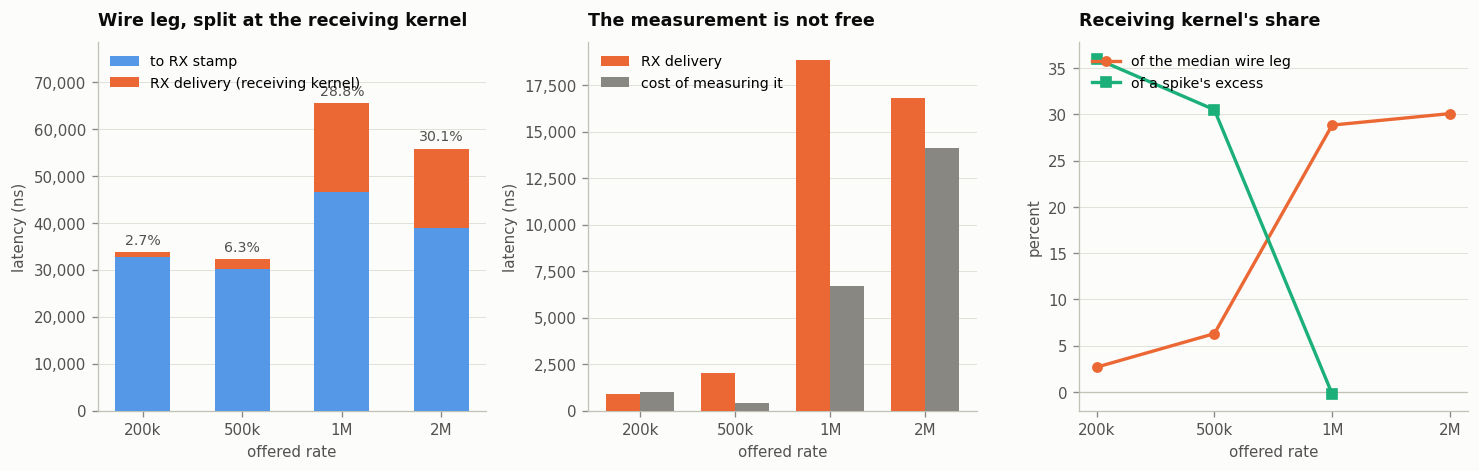

In [28]:
wl = pd.read_csv(PLOTS / "wire_leg_split.csv")
one = wl[wl["receivers"] == 1].sort_values("rate")

fig, axes = plt.subplots(1, 3, figsize=(12.4, 4.0))

# 1. the split, stacked
ax = axes[0]
x = np.arange(len(one))
ax.bar(x, one["to_rx_stamp_p50"], width=0.55, color=ORD4[1], label="to RX stamp", zorder=3)
ax.bar(x, one["rx_delivery_p50"], bottom=one["to_rx_stamp_p50"], width=0.55,
       color=CAT[1], label="RX delivery (receiving kernel)", zorder=3)
for i, (_, r) in enumerate(one.iterrows()):
    ax.annotate(f"{r['rx_share_of_wire_pct']:.1f}%", (i, r["wire_p50"]),
                textcoords="offset points", xytext=(0, 5), ha="center",
                color=INK2, fontsize=8.5)
ax.set_xticks(x); ax.set_xticklabels([rate_fmt(v) for v in one["rate"]])
ax.set_ylim(0, one["wire_p50"].max() * 1.2)
ax.set_title("Wire leg, split at the receiving kernel")
style(ax, ylabel="latency (ns)", xlabel="offered rate")
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(ns))
ax.legend(loc="upper left")

# 2. RX delivery against the cost of measuring it
ax = axes[1]
w = 0.36
ax.bar(x - w / 2, one["rx_delivery_p50"], width=w, color=CAT[1],
       label="RX delivery", zorder=3)
ax.bar(x + w / 2, one["tstamp_overhead_p50"], width=w, color=MUTED,
       label="cost of measuring it", zorder=3)
ax.set_xticks(x); ax.set_xticklabels([rate_fmt(v) for v in one["rate"]])
ax.set_ylim(bottom=0)
ax.set_title("The measurement is not free")
style(ax, ylabel="latency (ns)", xlabel="offered rate")
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(ns))
ax.legend(loc="upper left")

# 3. share of the wire leg, and of a spike
ax = axes[2]
# Spike shares are computed in the write-up from the per-message legs; the median share
# comes straight from the aggregate.
spike_share = {200000: 36.0, 500000: 30.5, 1000000: -0.2}
med = one["rx_share_of_wire_pct"].to_numpy(float)
spk = np.array([spike_share.get(int(r), np.nan) for r in one["rate"]])
ax.plot(x, med, marker="o", color=CAT[1], label="of the median wire leg", zorder=3)
ax.plot(x, spk, marker="s", color=CAT[2], label="of a spike's excess", zorder=3)
ax.axhline(0, color=AXIS, linewidth=0.8, zorder=2)
ax.set_xticks(x); ax.set_xticklabels([rate_fmt(v) for v in one["rate"]])
ax.set_title("Receiving kernel's share")
style(ax, ylabel="percent", xlabel="offered rate")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

In [29]:
t9d = wl[["rate", "receivers", "shm_p50", "wire_p50", "to_rx_stamp_p50",
          "rx_delivery_p50", "rx_share_of_wire_pct", "plain_wire_p50",
          "tstamp_overhead_p50"]].copy()
t9d.columns = ["rate", "receivers", "source ring", "wire", "to RX stamp",
               "RX delivery", "RX share %", "wire, no timestamps", "cost of measuring"]
table(t9d.style.format({c: "{:,.0f}" for c in
                        ["rate", "source ring", "wire", "to RX stamp", "RX delivery",
                         "wire, no timestamps", "cost of measuring"]}, na_rep="-")
      .hide(axis="index"),
      "Table 9d - wire leg split, medians in ns, cross-host")

Table 9d - wire leg split, medians in ns, cross-host


rate,receivers,source ring,wire,to RX stamp,RX delivery,RX share %,"wire, no timestamps",cost of measuring
"200,000",1,292,"33,744","32,836",908,2.690000,"32,733","1,011"
"500,000",1,289,"32,258","30,223","2,035",6.310000,"31,823",435
"1,000,000",1,740,"65,445","46,571","18,874",28.840000,"58,752","6,693"
"2,000,000",1,853,"55,812","39,021","16,791",30.080000,"41,689","14,123"
"200,000",10,"5,967","34,103","33,132",971,2.850000,-,-


### And the bursts are not in the receiving kernel either

The tail arrives in runs of consecutive messages. Taking the worst 0.01% of wire legs and
asking how much of their excess over the median sits in RX delivery:

| rate | wire excess during a spike | of which RX delivery | share | burst size |
|---|---|---|---|---|
| 200k | 2,117,687 | 761,636 | 36% | 206 messages |
| 500k | 247,558 | 75,481 | 31% | 86 messages |
| 1M | 3,793,591 | **−6,999** | **−0.2%** | 625 messages |

At 200k and 500k about a third of a spike is the receiving kernel stalling — median delivery
of 908 ns rising to 762 µs during an event, an 800-fold jump. At 1M the spikes are
**entirely upstream**: RX delivery during a spike is *lower* than its own median, 11.9 µs
against 18.9 µs. Which follows, once you consider what a spike is at that rate — a datagram
held up before the receiver arrives at a receiver that is therefore idle, and is picked up
at once.

**Verdict: the AF_XDP receive path is not worth its privileged step.** At the rates this
task centres on it could win about a microsecond of thirty-four. At 1M, where the receiving
kernel does cost 12–19 µs once the measurement's own cost is subtracted, the events that
dominate the far tail are upstream of it and would survive the change. What remains is in
the one place software timestamps cannot reach — sender transmit, the two NICs, the fabric —
and reaching it would need hardware timestamping, which was not attempted.

Fan-out changes none of this. At ten destinations the source-ring wait grows from 292 ns to
5,967 ns, which is the replication cost landing exactly where the send-mechanism work put
it, while RX delivery stays at 971 ns and the wire leg is unchanged.

## 9e. Two attempts on the tail, and what repeating them cost

Sections 9b–9d tried to *find* the tail by decomposing the path and ran out of road: the 32.8 µs
between the sender's pre-send stamp and the receiving kernel's stamp cannot be split further
without NIC hardware timestamps, which were not attempted here. So two changes tried to *avoid* the tail
instead — and this section is mostly about what happened when they were measured a second time.

- **path diversity** sends every datagram twice over **distinct source ports**, so the four-tuple
  that equal-cost path selection hashes on differs. Two schedulings were built: `--dual-path`
  submits both copies inline, and `--dup-path` gives redundancy its own sockets and writes to them
  only when the source ring is empty, so a copy can never delay a real message. The receiver needs
  no new code either way, because the monotonic gate already publishes whichever copy arrives first.
- **split polling** runs the receiver as a polling thread and a publishing thread over an SPSC ring,
  on the theory that a single-threaded loop stops busy-polling exactly when it falls behind.

**Path diversity looks like a measured trade — 5.8× off p99.99 for 10% onto p50 — and neither half
survives a second session.** The left panel is why. Three runs of the *identical* no-redundancy
configuration produced p99.99 values of 81,133, 921,223 and 1,172,844 ns — a **14.5× spread between
runs that differ in nothing at all**. Against that, a single baseline-versus-treatment pairing tells
you which window you sampled, not which configuration is better. The p50 half fails for a related
reason: per-rep spreads measure variation *inside* a window and cannot see the 8.8 µs of clock-offset
drift *between* two configurations' windows.

**What to look for:** the left panel shows the redundancy runs (n=6) all falling below the two
worst baselines (n=3), which is the direction the mechanism predicts — two draws from the tail
beating one. It is 13 of 18 pairwise comparisons and an exact one-sided Mann–Whitney p of 0.19, so
it is suggestive and *not* established, and it would be a mistake to report it as more.

The middle panel is the result that does hold, and it is measured on the receiver's own clock so no
offset correction is possible or needed. Redundancy costs about 5–6 µs at p99, all of it inside the
receiving kernel — and **it costs the same regardless of how the copy is submitted.** Four
mechanisms span 237 ns, or 3.2%. The rightmost bar is the decisive one: AF_XDP transmits through
`dev_direct_xmit`, sharing neither qdisc nor hardware transmit queue with the primary, and it is
indistinguishable from pushing both copies back-to-back down a single socket. Transmit-side
contention is not the mechanism, and no bypass on the send path can reach it.

The right panel closes the last escape route. Doubling the datagram rate doubles the receiver's
`recv` transitions, which is the one regime where io_uring's multishot receive should finally have a
call to save. It is immune to the penalty — and irrelevant, because its absolute p99 is 1.98× worse
than the kernel path's *with redundancy already on*. The penalty is masked by a larger constant
cost, not removed.

Split polling refutes itself for a simpler reason, in the table below: its handoff queue never held
more than **4 datagrams of 8,192**, so the publisher never fell behind and the feedback loop the
design exists to break was never running. Only its cost remains — the publish leg from 52 ns to
505 ns.

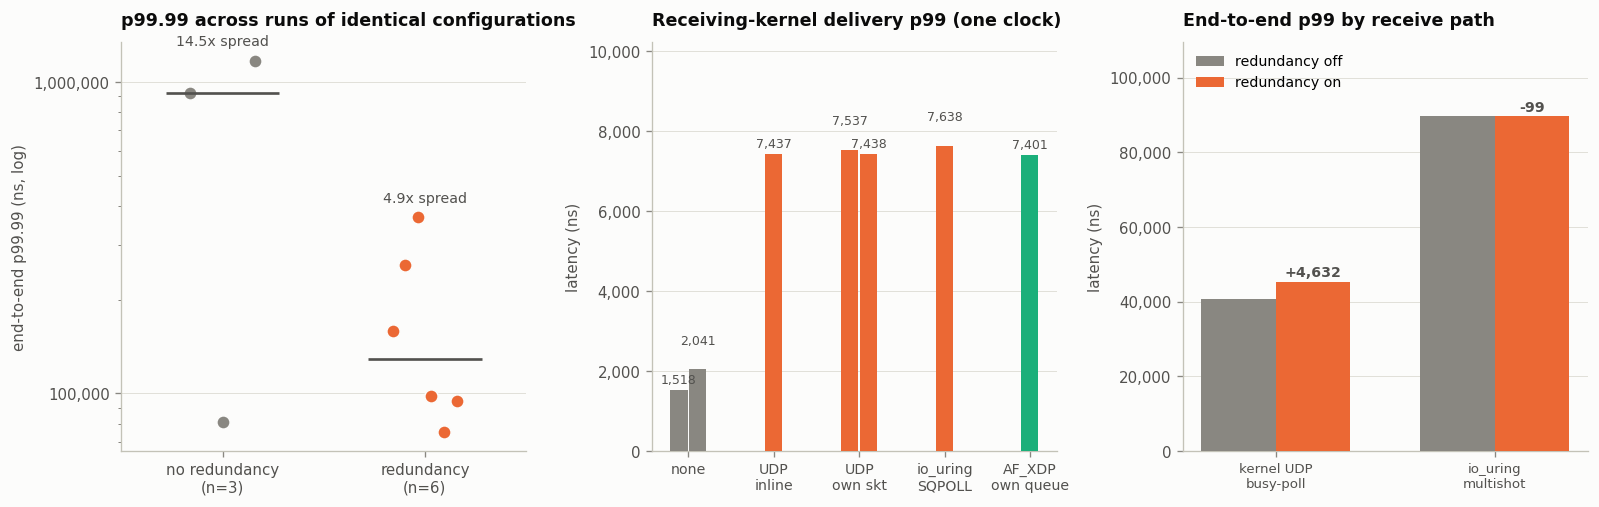

In [30]:
btv = pd.read_csv(PLOTS / "baseline_tail_variance.csv")
sm  = pd.read_csv(PLOTS / "redundancy_send_mechanism.csv")
rb  = pd.read_csv(PLOTS / "redundancy_receive_backend.csv")

fig, axes = plt.subplots(1, 3, figsize=(13.4, 4.3))

# 1. Why no single pairing settles the far tail: the baseline itself is not reproducible.
ax = axes[0]
groups = [("no redundancy", btv[btv["redundancy"] == "off"]["e2e_p9999"], MUTED),
          ("redundancy",    btv[btv["redundancy"] == "on"]["e2e_p9999"],  CAT[1])]
for xi, (label, vals, colour) in enumerate(groups):
    # Jitter is deterministic (evenly spaced by index), because a notebook that plots
    # different dots on every run is not a record of anything.
    v = list(vals)
    offs = np.linspace(-0.16, 0.16, len(v)) if len(v) > 1 else [0.0]
    ax.scatter([xi + o for o in offs], v, s=64, color=colour, zorder=3,
               edgecolor=SURFACE, linewidth=1.0)
    ax.hlines(np.median(v), xi - 0.28, xi + 0.28, color=INK2, linewidth=1.6, zorder=4)
    ax.annotate(f"{max(v)/min(v):.1f}x spread", (xi, max(v)), textcoords="offset points",
                xytext=(0, 9), ha="center", color=INK2, fontsize=8.5)
ax.set_xticks([0, 1]); ax.set_xticklabels(["no redundancy\n(n=3)", "redundancy\n(n=6)"])
ax.set_xlim(-0.5, 1.5)
ax.set_yscale("log")
ax.set_title("p99.99 across runs of identical configurations")
style(ax, ylabel="end-to-end p99.99 (ns, log)")
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(ns))

# 2. The cost that does replicate, and its indifference to the send mechanism.
ax = axes[1]
lab = {"none": "none", "dual-path": "UDP\ninline", "dup-leg-udp": "UDP\nown skt",
       "dup-leg-iouring": "io_uring\nSQPOLL", "dup-leg-xdp": "AF_XDP\nown queue"}
order = ["none", "dual-path", "dup-leg-udp", "dup-leg-iouring", "dup-leg-xdp"]
xs, vals, cols = [], [], []
for i, cfg in enumerate(order):
    rows = sm[sm["config"] == cfg]
    for j, (_, r) in enumerate(rows.iterrows()):
        xs.append(i + (j - (len(rows) - 1) / 2) * 0.22)
        vals.append(r["rx_delivery_p99"])
        # AF_XDP is the one row that shares no queue with the primary: colour it apart.
        cols.append(MUTED if cfg == "none" else (CAT[2] if cfg == "dup-leg-xdp" else CAT[1]))
ax.bar(xs, vals, width=0.20, color=cols, zorder=3)
# Two sessions measured some configurations, so bars come in pairs; stagger the value
# labels vertically or the pairs overprint each other.
for n, (x, v) in enumerate(zip(xs, vals)):
    ax.annotate(f"{v:,.0f}", (x, v), textcoords="offset points",
                xytext=(0, 4 + 11 * (n % 2)), ha="center", color=INK2, fontsize=7.5)
ax.set_xticks(range(len(order))); ax.set_xticklabels([lab[c] for c in order], fontsize=8.5)
ax.set_ylim(0, max(vals) * 1.34)
ax.set_title("Receiving-kernel delivery p99 (one clock)")
style(ax, ylabel="latency (ns)")
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(ns))

# 3. The receive path: immune to the penalty, and twice as slow anyway.
ax = axes[2]
w, x = 0.34, np.arange(2)
backends = ["kernel UDP + SO_BUSY_POLL", "io_uring multishot + provided buffers"]
off = [rb[(rb.receive_backend == b) & (rb.redundancy == "off")]["e2e_p99"].iloc[0] for b in backends]
on  = [rb[(rb.receive_backend == b) & (rb.redundancy == "on")]["e2e_p99"].iloc[0] for b in backends]
ax.bar(x - w/2, off, width=w, color=MUTED, label="redundancy off", zorder=3)
ax.bar(x + w/2, on,  width=w, color=CAT[1], label="redundancy on", zorder=3)
for xi, a, b in zip(x, off, on):
    ax.annotate(f"{b-a:+,.0f}", (xi + w/2, b), textcoords="offset points",
                xytext=(0, 3), ha="center", color=INK2, fontsize=8.5, fontweight="600")
ax.set_xticks(x); ax.set_xticklabels(["kernel UDP\nbusy-poll", "io_uring\nmultishot"], fontsize=8)
ax.set_ylim(0, max(off + on) * 1.22)
ax.set_title("End-to-end p99 by receive path")
style(ax, ylabel="latency (ns)")
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(ns))
ax.legend(loc="upper left")

fig.tight_layout()
plt.show()

In [31]:
rep = pd.read_csv(PLOTS / "redundancy_replication.csv")
t = rep.copy()
t.columns = ["percentile", "s1 base", "s1 dual", "s1 delta",
             "s2 base", "s2 dual", "s2 delta", "replicates?"]
table(t.style.format({c: "{:,.0f}" for c in t.columns
                      if c not in ("percentile", "replicates?")}).hide(axis="index"),
      "Table 9e - path diversity against its baseline, in ns, measured twice. The p50 and "
      "p99.99 claims reverse sign between sessions and are withdrawn; the p99 cost is the "
      "only column that replicates. Session 1's spreads were non-overlapping per-rep, which "
      "is exactly the reassurance that does not survive between-window clock drift.")

Table 9e - path diversity against its baseline, in ns, measured twice. The p50 and p99.99 claims reverse sign between sessions and are withdrawn; the p99 cost is the only column that replicates. Session 1's spreads were non-overlapping per-rep, which is exactly the reassurance that does not survive between-window clock drift.


percentile,s1 base,s1 dual,s1 delta,s2 base,s2 dual,s2 delta,replicates?
p50,"33,071","36,374","3,303","34,470","33,287","-1,183",sign flips
p99,"38,788","45,159","6,371","39,597","44,092","4,495",yes
p99.9,"57,832","58,122",290,"51,837","63,581","11,744",mixed
p99.99,"921,223","159,146","-762,077","81,133","259,100","177,967",sign flips


In [32]:
sp = pd.read_csv(PLOTS / "split_poll.csv")
t2 = sp[["config", "publish_p50", "rx_delivery_p50", "rx_delivery_p99",
         "e2e_p50", "e2e_p99", "e2e_p999", "queue_high_water", "queue_slots"]].copy()
t2.columns = ["config", "publish p50", "RX deliv p50", "RX deliv p99",
              "e2e p50", "e2e p99", "e2e p99.9", "queue high-water", "queue slots"]
table(t2.style.format({c: "{:,.0f}" for c in t2.columns if c != "config"},
                      na_rep="-").hide(axis="index"),
      "Table 9e - split polling, ns. The handoff queue never held more than 4 datagrams of "
      "8,192, so the publisher never fell behind and the feedback loop this design targets "
      "was not active. e2e p50 and p99 unchanged, publish leg 10x worse. Not shipped.")

Table 9e - split polling, ns. The handoff queue never held more than 4 datagrams of 8,192, so the publisher never fell behind and the feedback loop this design targets was not active. e2e p50 and p99 unchanged, publish leg 10x worse. Not shipped.


config,publish p50,RX deliv p50,RX deliv p99,e2e p50,e2e p99,e2e p99.9,queue high-water,queue slots
single-threaded,52,929,"2,058","31,817","37,973","47,851",-,-
split-poll,505,901,"2,236","31,810","38,956","62,996",4,"8,192"


## 10. Receive mode, on a real NIC

Kernel busy-poll lets the receiving thread pull packets off the device queue on its
own core instead of waiting for a softirq. Whether that helps depends entirely on
there being a device to poll.

**What to look for:** busy-poll is decisively better — 34.5 µs against 59.0 at the
median, and 54.5 against 184.7 at p99.9. Both series are cross-host over the NIC.

The mode is still derived from the bound address rather than exposed as a flag, for a
mechanical reason rather than a measured one: `SO_BUSY_POLL` is consulted by
`sk_busy_loop()`, which needs a NAPI-backed device. With no such device there is nothing
to poll, the blocking receive falls through to sleeping, and the option costs a wake-up
per message instead of saving one. That is a property of the path, so the transport works
it out rather than asking the operator to.

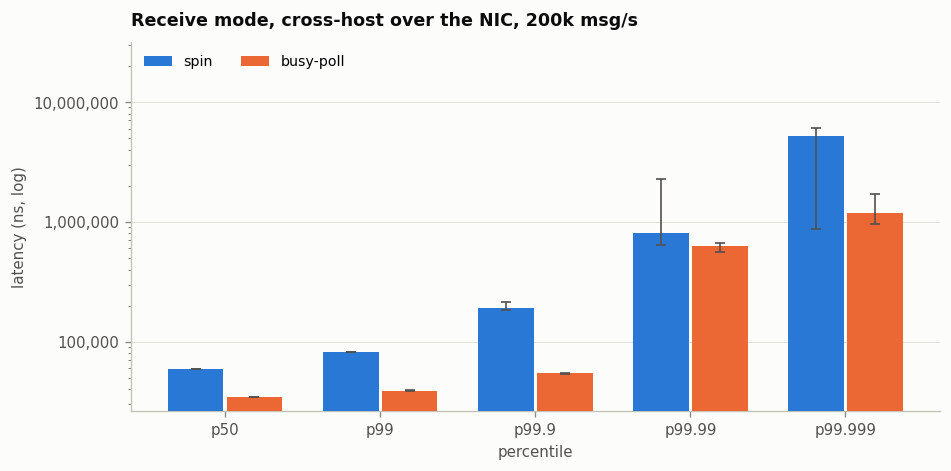

In [33]:
modes = pd.read_csv(PLOTS / "receive_modes.csv")
modes = modes.set_index("mode").loc[["spin", "busy-poll"]].reset_index()
cols5 = ["p50", "p99", "p99.9", "p99.99", "p99.999"]
x = np.arange(len(cols5)); w = 0.36

fig, ax = plt.subplots(figsize=(8.0, 4.0))
for i, (_, row) in enumerate(modes.iterrows()):
    vals = np.array([row[c] for c in cols5], float)
    lo = np.array([row[f"{c}_lo"] for c in cols5], float)
    hi = np.array([row[f"{c}_hi"] for c in cols5], float)
    off = (i - 0.5) * (w + 0.02)
    ax.bar(x + off, vals, width=w, color=CAT[i], label=row["mode"], zorder=3)
    ax.errorbar(x + off, vals, yerr=[vals - lo, hi - vals], fmt="none",
                ecolor=INK2, elinewidth=1, capsize=3, zorder=4)
ax.set_yscale("log")
ax.set_xticks(x); ax.set_xticklabels(cols5)
ax.set_ylim(top=ax.get_ylim()[1] * 4)
ax.set_title("Receive mode, cross-host over the NIC, 200k msg/s")
style(ax, ylabel="latency (ns, log)", xlabel="percentile")
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(ns))
ax.legend(loc="upper left", ncols=2)
plt.tight_layout(); plt.show()

In [34]:
t10 = modes[["mode", "samples", "p50", "p99", "p99.9", "p99.99", "p99.999", "max"]].copy()
t10.columns = ["mode", "samples/run", "p50", "p99", "p99.9", "p99.99", "p99.999", "max"]
table(t10.style.format(thousands=",").hide(axis="index"),
      "Table 10 - busy-poll wins through p99.9; beyond that both are inside "
      "drain-event territory")

Table 10 - busy-poll wins through p99.9; beyond that both are inside drain-event territory


mode,samples/run,p50,p99,p99.9,p99.99,p99.999,max
spin,"9,983,616","59,046","82,863","191,876","801,353","5,206,308","6,446,627"
busy-poll,"9,983,616","34,611","39,156","54,522","634,221","1,183,123","2,066,444"


## 11. Redundancy and batching hand off without configuration

Both follow one principle: use spare capacity, never delay a message. The sender
re-sends the previous datagram only when the source ring is empty, so redundancy
consumes time it had nothing better to do with, and batching packs whatever is
already available without ever waiting.

**What to look for:** duplication holds at 100% to 100k msg/s, is still 78% at 500k,
and reaches zero by 1M — before packet rate becomes the constraint identified in
figure 7. Batching rises to take over as it does. No threshold, no knob.

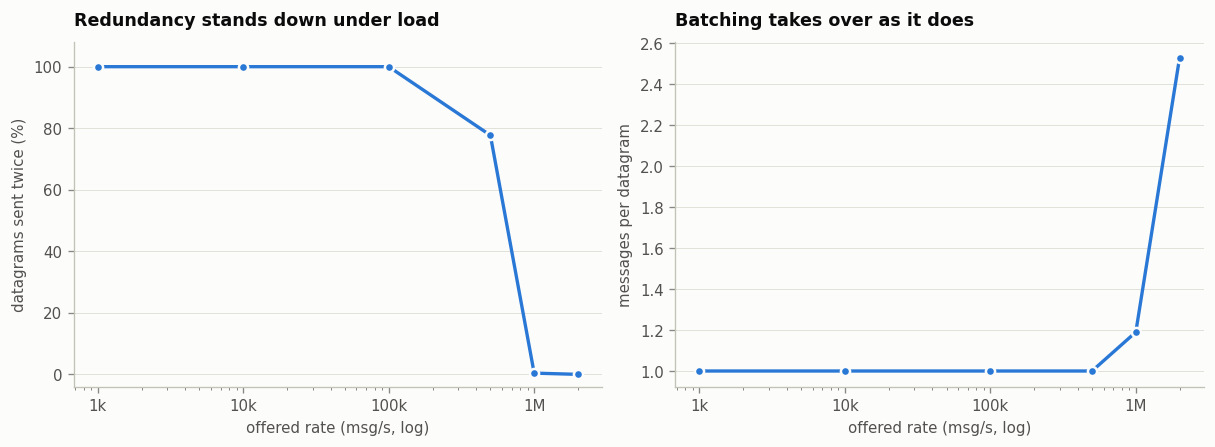

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.8))
ax = axes[0]
ax.plot(ad["rate"], ad["duplication_pct"], color=ORD4[2], marker="o",
        markeredgecolor=SURFACE, markeredgewidth=1.5, zorder=3)
ax.set_xscale("log"); ax.set_ylim(-4, 108)
ax.set_title("Redundancy stands down under load")
style(ax, ylabel="datagrams sent twice (%)", xlabel="offered rate (msg/s, log)")
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(rate_fmt))

ax = axes[1]
ax.plot(ad["rate"], ad["frames_per_datagram"], color=ORD4[2], marker="o",
        markeredgecolor=SURFACE, markeredgewidth=1.5, zorder=3)
ax.set_xscale("log")
ax.set_title("Batching takes over as it does")
style(ax, ylabel="messages per datagram", xlabel="offered rate (msg/s, log)")
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(rate_fmt))
plt.tight_layout(); plt.show()

## 12. Message footprint

The original harness format carried every price and size twice (a `double` and a
scaled integer), values derivable from others, 85 bytes of padding across three
types, and the symbol and venue as 32 bytes of text on every message. Field-by-field
reasoning is in the write-up; `harness/include/message.h` is the result.

**What to look for:** the largest frame sets the shared-memory ring slot size, so
shrinking `OrderBook` shrinks every ring hop too. Smaller messages are also what let
batching pack more per datagram, which is the mechanism keeping packet rate below the
NIC's limit in figure 7.

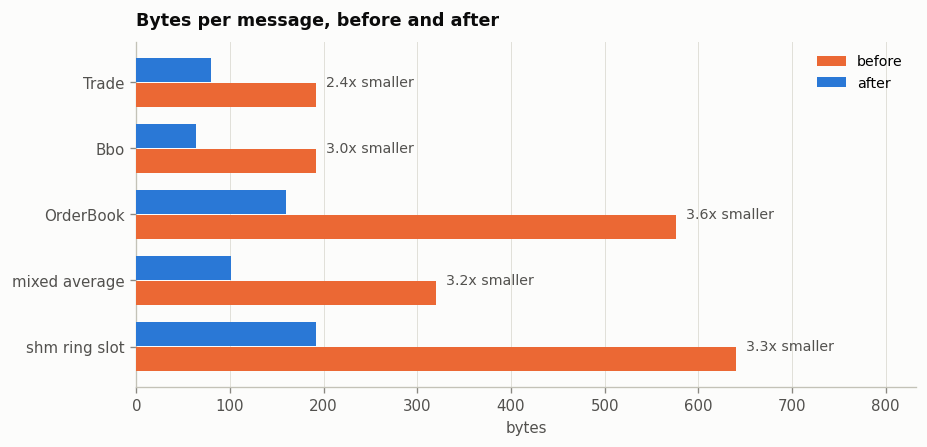

In [36]:
sizes = pd.read_csv(PLOTS / "message_sizes.csv")
y = np.arange(len(sizes)); h = 0.36

fig, ax = plt.subplots(figsize=(7.8, 3.8))
ax.barh(y + (h + 0.02) / 2, sizes["before_bytes"], height=h, color=CAT[1],
        label="before", zorder=3)
ax.barh(y - (h + 0.02) / 2, sizes["after_bytes"], height=h, color=CAT[0],
        label="after", zorder=3)
for i, row in sizes.iterrows():
    ax.annotate(f"{row['before_bytes']/row['after_bytes']:.1f}x smaller",
                (row["before_bytes"], i), textcoords="offset points",
                xytext=(6, 0), va="center", color=INK2, fontsize=8.5)
ax.set_yticks(y); ax.set_yticklabels(sizes["message"]); ax.invert_yaxis()
ax.set_xlim(0, sizes["before_bytes"].max() * 1.30)
ax.set_title("Bytes per message, before and after")
style(ax, xlabel="bytes", grid_axis="x")
ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

## 13. A routed long-haul path

Every figure so far comes from a directly-attached path: one hop, ~35 µs one way. This section
is a second host pair over a **routed inter-region path** at ~35 *milliseconds* one way -- three
orders of magnitude longer, which inverts what is worth measuring. The relay's own cost, ~620 ns,
is 0.002% of this path and cannot be seen at all. What can be seen is whether the design's
*rules* survive a network permitted to reorder, drop and re-route.

**What to look for:** the left panel is the result that matters. The delivery gate publishes only
strictly increasing sequence ids, so a reordered datagram is *dropped*, not delivered late -- on a
multi-path routed network that could have discarded a real fraction of the stream. It discarded
**nothing**: zero reordered datagrams in 1,549,105 across three rates. The strictness that buys
deduplication, late-drop and gap accounting in a single rule turns out to cost nothing here
either. Path MTU is also exactly 1500 end to end, so nothing fragments.

The middle panel is the cost of distance. Loss runs 20-80× the direct path's and climbs with
offered rate, reaching 0.18% at 50k msg/s. Note the burst column in the table below: the 10k run
lost 133 datagrams in a *single* event, and the 50k run averaged 20.6 consecutive. Loss here is
outages, not independent drops.

The right panel is the part that reads backwards until you know the mechanism: the **highest**
rate has the lowest median and the tightest tail. Same effect as on the direct path and the same
cause -- at 1,000 msg/s messages arrive a millisecond apart and every one meets a cold cache,
while at 50,000 the receiver is warm and already spinning. The receiving kernel's delivery leg
falls from 3,470 ns to 1,197 ns across the sweep.

Two things this path settles that the short one could not. **Absolute one-way latency is finally
trustworthy**: the inter-host clock offset measured 27,155 ns -- about 30× the short pair's, two
regions rather than two racks -- but that is 0.08% of a 33.5 ms path, and the measured one-way
sits within 0.3% of half the ICMP round trip. And **redundancy is decisively answered**: six
interleaved blocks resolve it as a net *cost* — about 9% more frames never delivered, every block
agreeing in sign (sign p = 0.031) — because the arm without redundancy dropped its ~1,920
datagrams in one ~39 ms outage, and a copy sent microseconds later is inside that outage. No
latency metric separates in either direction, which the table below shows and explains.

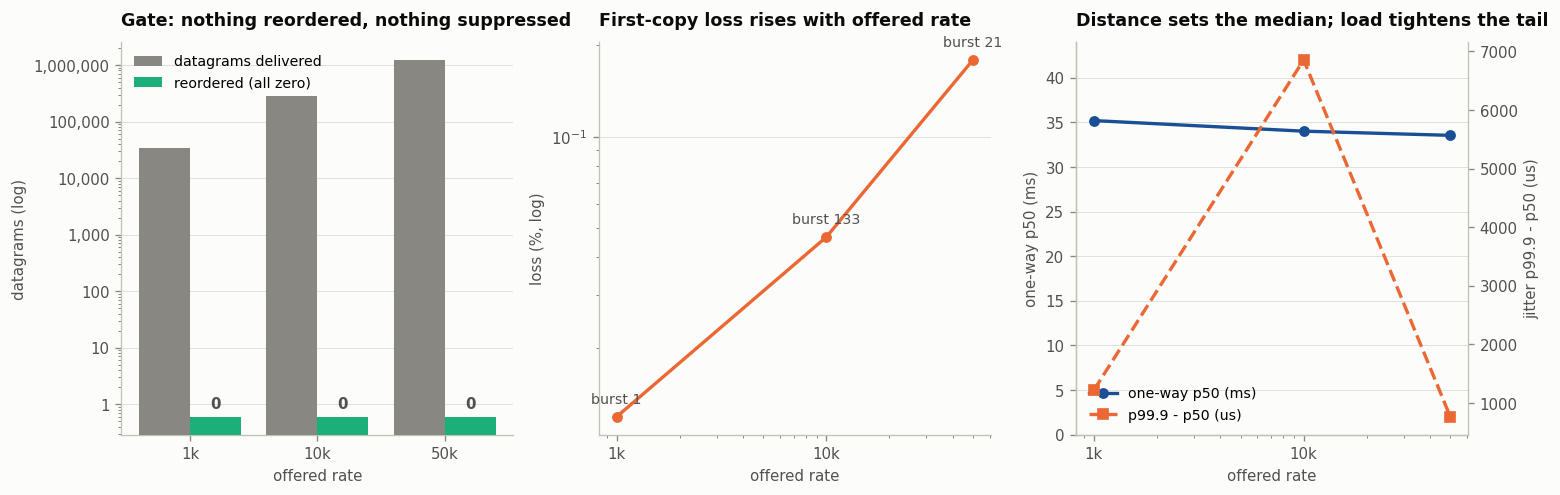

In [37]:
l3 = pd.read_csv(PLOTS / "l3_path.csv")
l3 = l3.sort_values("rate")

fig, axes = plt.subplots(1, 3, figsize=(13.0, 4.2))
x = np.arange(len(l3))

# 1. The design question: does the monotonic gate throw anything away here?
ax = axes[0]
ax.bar(x - 0.2, l3["datagrams"], width=0.4, color=MUTED, label="datagrams delivered", zorder=3)
# Reordered and suppressed are both exactly zero, which a log axis cannot draw -- so they are
# stated rather than plotted, which is also the honest way to show a zero.
ax.bar(x + 0.2, np.maximum(l3["reorder"], 0.6), width=0.4, color=CAT[2],
       label="reordered (all zero)", zorder=3)
for xi, (_, r) in zip(x, l3.iterrows()):
    ax.annotate("0", (xi + 0.2, 0.7), textcoords="offset points", xytext=(0, 3),
                ha="center", color=INK2, fontsize=9, fontweight="600")
ax.set_yscale("log")
ax.set_xticks(x); ax.set_xticklabels([rate_fmt(v) for v in l3["rate"]])
ax.set_title("Gate: nothing reordered, nothing suppressed")
style(ax, ylabel="datagrams (log)", xlabel="offered rate")
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(ns))
ax.legend(loc="upper left")

# 2. Loss against rate, with the burst length that makes redundancy useless.
ax = axes[1]
ax.plot(l3["rate"], l3["loss_frac"] * 100, color=CAT[1], marker="o", zorder=3)
for _, r in l3.iterrows():
    ax.annotate(f"burst {r['mean_burst']:.0f}", (r["rate"], r["loss_frac"] * 100),
                textcoords="offset points", xytext=(0, 8), ha="center",
                color=INK2, fontsize=8.5)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_title("First-copy loss rises with offered rate")
style(ax, ylabel="loss (%, log)", xlabel="offered rate")
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(rate_fmt))

# 3. Latency: distance dominates, and load helps.
ax = axes[2]
base = l3["wire_p50"] / 1e6
ax.plot(l3["rate"], base, color=ORD4[3], marker="o", label="one-way p50 (ms)", zorder=3)
ax2 = ax.twinx()
ax2.plot(l3["rate"], (l3["wire_p999"] - l3["wire_p50"]) / 1e3, color=CAT[1],
         marker="s", linestyle="--", label="p99.9 - p50 (us)", zorder=3)
ax2.set_ylabel("jitter p99.9 - p50 (us)", color=INK2)
ax2.spines["top"].set_visible(False)
ax.set_xscale("log")
ax.set_ylim(0, base.max() * 1.25)
ax.set_title("Distance sets the median; load tightens the tail")
style(ax, ylabel="one-way p50 (ms)", xlabel="offered rate")
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(rate_fmt))
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="lower left")

fig.tight_layout()
plt.show()

In [38]:
t = l3[["rate", "datagrams", "reorder", "gate_suppressed", "loss_frac", "mean_burst",
        "wire_p50", "wire_p999", "rx_delivery_p50", "shm_p50", "publish_p50"]].copy()
t["loss_frac"] = t["loss_frac"] * 100
t.columns = ["rate", "datagrams", "reordered", "suppressed", "loss %", "mean burst",
             "one-way p50", "one-way p99.9", "RX deliv p50", "src-ring p50", "publish p50"]
table(t.style.format({"rate": "{:,.0f}", "datagrams": "{:,.0f}", "loss %": "{:.4f}",
                      "mean burst": "{:.1f}", "one-way p50": "{:,.0f}",
                      "one-way p99.9": "{:,.0f}", "RX deliv p50": "{:,.0f}",
                      "src-ring p50": "{:,.0f}", "publish p50": "{:,.0f}"}).hide(axis="index"),
      "Table 13 - routed long-haul path, ns unless marked. Reordered and suppressed are zero "
      "at every rate, which is the design question this pair existed to answer. Our own two "
      "legs (src-ring, publish) are unchanged from the direct path -- they do not depend on "
      "the network -- while the wire leg is a thousand times larger.")

Table 13 - routed long-haul path, ns unless marked. Reordered and suppressed are zero at every rate, which is the design question this pair existed to answer. Our own two legs (src-ring, publish) are unchanged from the direct path -- they do not depend on the network -- while the wire leg is a thousand times larger.


rate,datagrams,reordered,suppressed,loss %,mean burst,one-way p50,one-way p99.9,RX deliv p50,src-ring p50,publish p50
"1,000","33,505",0,0,0.0119,1.0,"35,198,838","36,417,785","3,470",444,40
"10,000","285,250",0,0,0.0466,133.0,"34,012,777","40,867,959","3,381",454,41
"50,000","1,230,350",0,0,0.1789,20.6,"33,542,789","34,306,023","1,197",305,45


In [39]:
ab = pd.read_csv(PLOTS / "l3_ab_paired.csv")
LBL = {"loss_pct": "first-copy loss %", "undelivered": "frames never delivered",
       "rx_delivery_p50": "RX delivery p50", "rx_delivery_p99": "RX delivery p99",
       "wire_p50": "wire leg p50", "e2e_p50": "end-to-end p50", "e2e_p99": "end-to-end p99",
       "e2e_p999": "end-to-end p99.9", "e2e_p9999": "end-to-end p99.99",
       "shm_p50": "source-ring wait p50"}
t2 = ab.copy()
t2["metric"] = t2["metric"].map(lambda m: LBL.get(m, m))
t2["clock"] = np.where(t2["cross_host"] == 1, "two clocks", "one clock")
t2["verdict"] = np.where(t2["resolved"] == 1, "RESOLVED", "not resolved")
t2 = t2[["metric", "clock", "median_diff", "lo", "hi", "null_spread", "n_blocks",
         "sign_p", "verdict"]]
t2.columns = ["metric", "clock", "on - off", "lo", "hi", "reference's own spread",
              "blocks", "sign p", "verdict"]
table(t2.style.format({"on - off": "{:+,.4g}", "lo": "{:+,.4g}", "hi": "{:+,.4g}",
                       "reference's own spread": "{:,.4g}", "sign p": "{:.3f}"})
      .hide(axis="index"),
      "Table 13 - redundancy on the routed path across six interleaved counterbalanced blocks, "
      "twelve of twelve arm-runs valid, arms two minutes apart within a block. The two RESOLVED "
      "rows are the two needing no clock: loss and delivery are counters on the receiving host, "
      "and both move the same way in all six blocks. Everything cross-host is unresolved because "
      "the reference arm's own median moves 1.1 ms between blocks -- an effect smaller than that "
      "column is not resolvable on this path however many blocks are run.")

Table 13 - redundancy on the routed path across six interleaved counterbalanced blocks, twelve of twelve arm-runs valid, arms two minutes apart within a block. The two RESOLVED rows are the two needing no clock: loss and delivery are counters on the receiving host, and both move the same way in all six blocks. Everything cross-host is unresolved because the reference arm's own median moves 1.1 ms between blocks -- an effect smaller than that column is not resolvable on this path however many blocks are run.


metric,clock,on - off,lo,hi,reference's own spread,blocks,sign p,verdict
first-copy loss %,one clock,+0.0129,+0.0121,+0.0361,0.0029,6,0.031,RESOLVED
frames never delivered,one clock,+170,+135,+217,36,6,0.031,RESOLVED
source-ring wait p50,one clock,-9.5,-143,+5,141,6,0.219,not resolved
RX delivery p50,one clock,+66,-43,+169,95,6,0.688,not resolved
RX delivery p99,one clock,-136.5,-916,+340,"1,125",6,1.000,not resolved
wire leg p50,two clocks,+7.753e+04,-8.241e+05,+4.579e+05,1.111e+06,6,0.688,not resolved
end-to-end p50,two clocks,+7.757e+04,-8.25e+05,+4.577e+05,1.111e+06,6,0.688,not resolved
end-to-end p99,two clocks,+4.879e+04,-2.368e+06,+5.236e+05,2.424e+06,6,0.688,not resolved
end-to-end p99.9,two clocks,-6.546e+05,-3.56e+06,+1.157e+06,3.882e+06,6,0.688,not resolved
end-to-end p99.99,two clocks,-7.557e+05,-4.113e+06,+1.093e+06,4.503e+06,6,1.000,not resolved


## Clock synchronisation

Every cross-host figure is `recv_ts` on the receiving host minus `send_ts_ns` stamped
on the sending host — two clocks — so it is worth stating what that does and does not
affect.

**What we rely on.** chrony keeps the directly-attached pair synchronised to well within
3 microseconds; measured RMS offset during those runs was a few hundred nanoseconds on
both. `chronyc tracking` is captured before *and* after each long run rather than once at
the start, and an idle round-trip probe measures the offset directly.

**The two paths sit in opposite regimes, and it matters.** On the short path the offset was
separately measured wandering across 8.8 µs over an hour — the same size as the effects being
looked for, which is why two apparent results did not survive repetition and why
comparisons now run as interleaved blocks. On the routed long-haul path the offset is far
larger in absolute terms, about 27 µs, but that is 0.08% of a 33.5 ms one-way, and the measured
one-way sits within 0.3% of half the ICMP round trip. **Long haul is the one regime here where
absolute one-way latency is trustworthy**, because the quantity finally dwarfs the uncertainty
in the clocks.

**A static offset is mostly harmless.** A constant offset shifts every sample
equally, so it biases absolute medians but cancels exactly in anything comparative —
distribution shape, the gap between p50 and p99.999, and every
configuration-versus-configuration result here. Nearly all conclusions in this
notebook are comparative.

**Drift is the real hazard**, because an offset that moves during a run smears the
distribution and can pass for tail latency. Hence the before-and-after capture.

**Which figures depend on it at all.** Of the four legs in figure 2, only the wire
leg spans two clocks. Source-ring, publish and post-publish are each measured on a
single host, and those are the legs carrying our own code's cost — so the claim that
our code contributes ~620 ns needs no clock agreement whatsoever. Three further
cross-checks: ICMP round-trip halved is an upper bound owing nothing to
synchronisation, and our one-way figures sit below it as expected since ICMP is
deprioritised; the drain-event slope in figure 4 matches the known message interval,
which it could not if clocks were drifting materially; and the four legs sum to the
independently measured end-to-end value (35,075 against 35,325 ns).

**Residual uncertainty, not claimed away.** chrony's root dispersion here is tens of
microseconds, which bounds accuracy against absolute UTC — but the relevant quantity
is the *relative* offset between hosts tracking the same sources, which is far
smaller. Absolute one-way latencies carry a small systematic uncertainty; the
comparative results do not. Tightening it would mean NIC hardware timestamping, or a
reflector design where one host stamps both departure and return. Neither was attempted:
everything here rests on software timestamps and the hosts' existing time sync.

## Conclusions

**What the measurements support.** Over a real NIC between two hosts on one subnet:
35 µs median, 39 µs at p99, 50 µs at p99.9, 68 µs at p99.99, and **zero loss across
the task's entire stated rate range** from 100 to 2M events per second. Latency is
essentially flat across that range — the *lowest* rate has the highest median,
because at 10 ms between messages everything is cold.

**Our transport is not the limiting factor, and the data says so precisely.** Of the
35 µs median, our sender accounts for 305 ns, publishing 50 ns, and the consumer's
pickup 264 ns — about 1.8% in total, staying under 1 µs even at p99.999. The other
98% is kernel TX, NIC, wire and kernel RX. There is no remaining optimisation in our
code that could move the median; the only lever left is bypassing the kernel network
stack.

**Spikes are bursty, not uniform, and that is the most useful thing we learned about
the tail.** Above 500 µs there are *no* isolated occurrences at all — 100% sit inside
bursts of consecutive messages, and a whole 20M-message run contains one to three of
them. All 213 messages over 1 ms are wire-dominated and arrive as consecutive sequence
ids whose latency falls at exactly the inter-message interval: a queue stalling ~2 ms
and then draining.

Two consequences. A far-tail percentile from a short run is meaningless, because
whether it captures a burst is luck. And the fix is not "shave microseconds" — it is to
find and remove one recurring stall.

**Loss follows packet rate, not message rate**, and batching is what exploits that:
the only loss observed is at the highest packets-per-second point, and doubling the
message rate from 1M to 2M *reduces* both packet rate and loss.

**Decisions the measurements drove, against prior reasoning.**

- *Connected sockets over `sendmmsg`.* The structural argument favoured `sendmmsg`
  and was wrong on a real NIC.
- *Busy-poll where there is a device to poll.* `SO_BUSY_POLL` needs a NAPI-backed
  device; without one it adds a wake-up per message rather than removing one. That is a
  property of the path, so the transport derives it instead of exposing a flag.
- *Duplication over retransmission or FEC.* Strictly monotonic delivery means a late
  repair cannot be inserted at all, so only redundancy that costs no latency is worth
  anything.
- *Format work over tuning.* Shrinking messages 3.2x did more for headroom than any
  socket or core setting.

## What was done since, and what it cost

Every avenue this work set out to try has now been attempted. The results are
mostly negative, which is worth more than a list of intentions:

- **io_uring — done, and it loses.** On the send side it produces no end-to-end difference that
  survives session drift. On the receive side it is decisively worse (69% at the median), and
  re-tested at twice the datagram rate — the one regime where a multishot receive should finally
  have a system call to save — it was 1.98× worse in absolute p99. It appears immune to extra
  load only because a larger constant cost masks it.
- **AF_XDP — done for the send path, and it could not answer what it was chosen for.** This NIC
  offers no zero-copy, so only copy mode is available, and copy mode keeps skb allocation and the
  driver path — precisely the kernel involvement that needed ruling out. It did confirm the
  send-cost model (37% off the send cycle, the largest of any mechanism) and is 4.6 µs *worse* end
  to end, because the saving moves into the wire leg. AF_XDP receive was priced from the receive
  timestamps at about a microsecond and judged not worth its privileged step.
- **A routed long-haul path — done, and it settled the design's biggest open risk.** Section 13:
  zero reordering in 1,549,105 datagrams, so the strictly-monotonic gate discards nothing even on
  a multi-path network, and MTU 1500 holds end to end. Loss is 20-80× the short path's.
- **Redundancy — measured on both paths, and it does not pay on either.** Loss arrives in bursts
  far longer than the gap between a datagram and its copy: 69-80 consecutive datagrams on the
  short path, and a single ~39 ms outage on the long one. Four-tuple diversity does not change
  that, and its one reproducible effect is a **cost** of ~5-6 µs at p99 living entirely inside the
  receiving kernel — invariant across four different send mechanisms, including AF_XDP on its own
  transmit queue, which shares neither qdisc nor hardware queue with the primary.
- **Two claims were withdrawn.** Path diversity appeared to buy 5.8× at p99.99 for 10% at the
  median; repeating it reversed the sign of both, because the baseline's own p99.99 varies 14.5×
  between identical runs and per-repetition spreads cannot see clock drift between windows.
  Section 9e is the retraction.
- **The measurement itself was audited.** Percentiles were being computed as the median of
  per-file percentiles, which understated far tails by up to 719% and one maximum by 115×;
  medians and p99s did not move. Comparisons now run as counterbalanced interleaved blocks with
  a paired sign test, and six blocks is a hard floor — with all blocks agreeing the smallest
  attainable two-sided p is 2/2ⁿ, so three blocks cannot reach significance at any effect size.

## Where to take it next

1. **The 32.8 µs opaque leg.** Between the sender's pre-send stamp and the receiving kernel's
   stamp sit sender transmit, both NICs and the fabric. Both *software* routes in are exhausted:
   AF_XDP copy mode keeps the driver path, and the software transmit stamp reflects completion
   rather than transmit. Splitting it further needs NIC hardware timestamps, which this work did
   not attempt — the one open item whose next step is a different technique rather than more
   analysis of data already collected.
2. **Loss at the 1-10% the task contemplates.** Neither path gets near it — 2.2e-05 on the short
   path, up to 1.8e-03 on the routed one. That regime has to be *induced* rather than found.
3. **A temporal stagger for the redundant copy**, held back by longer than a burst. The receiver
   needs no change, because the gate already absorbs a late copy. It trades latency for
   completeness, which is a policy choice worth exposing rather than deciding.
4. **The receive-side cost of redundancy** — ~5-6 µs at p99, entirely inside the receiving
   kernel and identical across four submission mechanisms, so it is the cost of taking delivery of
   twice the datagrams rather than of how they are sent. Two routes: a second receive socket on its
   own core, and an XDP program running the monotonic gate so the losing copy is dropped before
   skb allocation. The second is an operator action.
5. **Multicast or a relay tree for fan-out.** The packet budget divides achievable message rate by
   receiver count, so unicast replication cannot reach fifty receivers at any interesting rate.
   The only item here that changes an asymptote rather than a constant.

**Honest limitations.**

- p99.999 rests on ~200 observations per run and varies by a factor of two between repetitions.
  It is reported, but the drain event dominates it and it is not a property of the transport.
- Fan-out is measured to 10 independent receivers, and they share one host, so one NIC carries N
  copies where N hosts would each carry one. These figures are an upper bound on the design's
  cost rather than a prediction for N machines.
- **The SQPOLL drop burst was seen once and not repeated** — two of ten receivers lost about
  1,123 datagrams each in one of three repetitions. Not called a defect without repeat runs; not
  recommended meanwhile.
- The receiving kernel is split out and priced (908 ns of 33.7 µs at 200k; 12-19 µs of 65 µs at
  1M), which is what made the AF_XDP receive decision possible. The rest of the wire leg is not.
- The ~2 ms drain events are attributed only as far as "upstream of the receiving kernel". At 1M
  they are entirely upstream; at 200k and 500k about a third of the excess is the receiving kernel.
- One host is virtualised and one bare metal. We tested specifically for hypervisor-induced
  periodicity with simultaneous opposite-direction streams over 15 minutes and found none
  (autocorrelation at 300 s lag: −0.02 and −0.09).
- Rates above 50k msg/s on the routed path, and fan-out beyond one receiver there, were
  deliberately not attempted: loss was already climbing with offered rate on a shared long-haul
  link.